# Cetacean MLP — LODO experiments

This notebook deliberately restricts the
analysis to combinations that are statistically defensible, after looking at the prior
notebook's per-class support per dataset.

**Three experiments.**

1. **Joint vs. hierarchical (within-corpus baseline).** A single classifier over
   `{background, species_1, ..., species_k}` trained on the full corpus, group-stratified.
   Then a two-stage cascade: a binary mammal-vs-non-mammal detector followed by a
   species head trained on mammal rows. Headline question: does it pay to split the
   task in two, or does one head do as well?

2. **Joint LODO for detection + species.** Same joint label as Exp 1, but
   Leave-One-Dataset-Out across **11 datasets** (WATKINS held out of the held-out
   list, used only for training). All non-species, non-background classes
   (`anthropogenic`, and anything else that may surface) are folded into background
   before training - we don't care about those classes, only "is it a vocalisation"
   and "if so, which species". Per-fold metrics computed only over classes actually
   present in that held-out dataset.

3. **Pure species LODO.** Mammal rows only, species classification. The held-out
   folds are restricted to the **four** datasets where it actually makes sense:
   WATKINS, MONISH, ECOSS_testtrain, ALNITAK_CAVANILLES. WATKINS holds out
   `Balaenoptera_acutorostrata` from its eligible classes (only 17 rows, single
   dataset - un-transferable).

The cross-dataset support matrix that motivated these restrictions:

```
                    Bac  Bphy  Dunk  Ddel  Gme  Ggr  Oor   Pma  Sco  Ttr
ALNITAK_CAVANILLES   0    0     0    0    141  45    0   179   15   58
Adriatic_Sea         0    0     0    0      0   0    0     0    0  942
DCLDE_2026           0    0     0    0      0   0 21696    0    0    0
DOLPHINFREE          0    0     0  1150     0   0    0     0    0    0
DRYAD                0    0     0    0      0   0    0     0    0 2916
ECOSS_annot          0    0   466    0      0   0    0     0    0    0
ECOSS_enhanced       0    0    42    0      0   0   15    15   44   27
ECOSS_testtrain      0    0     0   40     26   0   22    20    0   19
FREMANTLE            0    0     0    0      0   0    0     0    0  332
MONISH               0   29     0    0    410 113   37     0    0   28
OLTREMARE            0    0     0    0      0   0    0     0    0 2904
WATKINS             17  510     0  102    144  81   39   875   85   24
```

(Bac=Balaenoptera_acutorostrata, Bphy=Balaenoptera_physalus, Dunk=Delphinidae_unknown,
Ddel=Delphinus_delphis, Gme=Globicephala_melas, Ggr=Grampus_griseus,
Oor=Orcinus_orca, Pma=Physeter_macrocephalus, Sco=Stenella_coeruleoalba,
Ttr=Tursiops_truncatus)


## 0. Setup

In [ ]:
import os, sys, json, time, warnings, copy
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    f1_score, precision_recall_fscore_support, confusion_matrix,
    classification_report, accuracy_score, balanced_accuracy_score,
)
from sklearn.model_selection import GroupShuffleSplit

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
np.random.seed(42); torch.manual_seed(42)


# DEVICE = torch.device('cpu')
# print(f"device: {DEVICE}  torch: {torch.__version__}")
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"device: {DEVICE}  torch: {torch.__version__}")


device: cuda  torch: 2.5.1+cu121


In [2]:
import os
import tensorflow as tf
import torch

os.environ["CUDA_VISIBLE_DEVICES"] = "0"

print(f"TF GPUs: {tf.config.list_physical_devices('GPU')}")
print(f"PyTorch: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    # Only use GPU 0
    tf.config.set_visible_devices(gpus[0], 'GPU')
    # Optional: prevent TF from grabbing all memory
    tf.config.experimental.set_memory_growth(gpus[0], True)
print(f"TF using: {tf.config.get_visible_devices('GPU')}")

2026-05-19 09:50:16.059479: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 09:50:16.113430: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-05-19 09:50:17.348497: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TF GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:2', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:3', device_type='GPU')]
PyTorch: NVIDIA L4
TF using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [ ]:
# ---------------------------------------------------------------------
# Paths - same as the previous experiments notebook.
# ---------------------------------------------------------------------
IN_DIR  = Path('/data2/mromaniuc/cet-det/alltogether/full_corpus_together/mlp_runs')                 # contains meta_all_with_taxonomy.parquet
PROJ_IN = Path('/data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input')          # contains X_all.npy
OUT_DIR = Path('./mlp_runs')
OUT_DIR.mkdir(exist_ok=True, parents=True)

META_PATH = IN_DIR / 'meta_all_with_taxonomy.parquet'
X_PATH    = PROJ_IN / 'X_all.npy'

print(f"meta:    {META_PATH}  exists={META_PATH.exists()}")
print(f"X_all:   {X_PATH}     exists={X_PATH.exists()}")
print(f"outputs: {OUT_DIR.resolve()}")


meta:    /data2/mromaniuc/cet-det/alltogether/preliminary/mlp_runs/meta_all_with_taxonomy.parquet  exists=True
X_all:   /data2/mromaniuc/cet-det/alltogether/full_exploration/dim_red/projector_input/X_all.npy     exists=True
outputs: /data2/mromaniuc/cet-det/alltogether/full_exploration/classifiers/mlp_runs


In [4]:
meta_all = pd.read_parquet(META_PATH)
X_all    = np.load(X_PATH, mmap_mode='r')
print(f"meta_all: {len(meta_all):,} rows  cols={len(meta_all.columns)}")
print(f"X_all:    {X_all.shape}  dtype={X_all.dtype}")

assert 'row' in meta_all.columns
assert 'group_key' in meta_all.columns
assert meta_all['row'].max() < len(X_all)
for c in ['label_t1','label_t2','label_t3','label_t4','label_t5']:
    assert c in meta_all.columns, f"missing taxonomy column: {c}"

ALL_DATASETS = sorted(meta_all['dataset'].unique().tolist())
print(f"\ndatasets in corpus: {ALL_DATASETS}")


meta_all: 247,630 rows  cols=64
X_all:    (247630, 1536)  dtype=float32

datasets in corpus: ['ALNITAK_CAVANILLES', 'Adriatic_Sea', 'DCLDE_2026', 'DOLPHINFREE', 'DRYAD', 'ECOSS_annot', 'ECOSS_enhanced', 'ECOSS_testtrain', 'FREMANTLE', 'MONISH', 'OLTREMARE', 'WATKINS']


## 1. Build the joint label

The joint label is `{background, all species}`. Per the task brief, anything that
isn't a species and isn't background - concretely `anthropogenic`, but also any
other non-species label that might show up - is folded into `background`. We do
not care about distinguishing anthropogenic noise from natural background; both
are "not a cetacean vocalisation".

Rows where neither a species nor a coarse-group label exists are dropped.


In [5]:
def build_joint_label(row):
    '''
    Returns one of:
      - the species name (from label_t4)
      - 'background' for everything else that's labelled (non-mammal of any kind:
        ambient, geophonic, anthropogenic, etc.)
      - None if the row has no usable label at all
    '''
    t4 = row['label_t4']
    if pd.notna(t4):
        return t4
    # Anything non-mammal that's been labelled - background, anthropogenic,
    # geophonic, ship noise, etc. - becomes 'background' for this task.
    t1 = row['label_t1']
    t2 = row['label_t2']
    if pd.notna(t1) and t1 == 'non_mammal':
        return 'background'
    if pd.notna(t2) and t2 in ('background', 'anthropogenic'):
        return 'background'
    return None


meta_joint = meta_all.copy()
meta_joint['label_joint'] = meta_joint.apply(build_joint_label, axis=1)
meta_joint = meta_joint.dropna(subset=['label_joint']).copy()

print(f"joint-labelled rows: {len(meta_joint):,}")
print(f"joint classes:       {meta_joint['label_joint'].nunique()}")
print()
print("class distribution:")
print(meta_joint['label_joint'].value_counts().to_string())
print()
print("per-dataset class counts:")
print(pd.crosstab(meta_joint['dataset'], meta_joint['label_joint']).to_string())


joint-labelled rows: 247,214
joint classes:       11

class distribution:
label_joint
background                    213606
Orcinus_orca                   21809
Tursiops_truncatus              7250
Delphinus_delphis               1292
Physeter_macrocephalus          1089
Globicephala_melas               721
Balaenoptera_physalus            539
Delphinidae_unknown              508
Grampus_griseus                  239
Stenella_coeruleoalba            144
Balaenoptera_acutorostrata        17

per-dataset class counts:
label_joint         Balaenoptera_acutorostrata  Balaenoptera_physalus  Delphinidae_unknown  Delphinus_delphis  Globicephala_melas  Grampus_griseus  Orcinus_orca  Physeter_macrocephalus  Stenella_coeruleoalba  Tursiops_truncatus  background
dataset                                                                                                                                                                                                                                        


## 2. Shared MLP probe

Same `1536 -> 512 -> 256 -> n_classes` architecture as the previous notebooks, same
training recipe (AdamW, class-balanced CE, early stopping on val macro-F1). Wrapped
in `train_eval_mlp(...)` so each experiment below just builds splits and calls it.

**Metric note.** `test_macro_f1` is computed over classes *actually present in the
test fold*, not the full training vocabulary. This is the right number for LODO:
classes the held-out dataset doesn't contain would only contribute zeros to a
full-vocab macro average, which is mathematically punishing and uninformative. We
also report `test_macro_f1_full_vocab` for the strict reading, plus accuracy and
balanced accuracy.


In [6]:
class MLP(nn.Module):
    def __init__(self, in_dim, n_classes, hidden=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev = [], in_dim
        for h in hidden:
            layers += [nn.Linear(prev, h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def train_mlp(Xtr, ytr, Xva, yva, n_classes,
              hidden=(512,256), dropout=0.3,
              lr=1e-3, weight_decay=1e-4, batch_size=1024,
              epochs=40, patience=6, class_weight=True, verbose=False):
    model = MLP(Xtr.shape[1], n_classes, hidden=hidden, dropout=dropout).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if class_weight:
        counts = np.bincount(ytr, minlength=n_classes).astype(np.float32)
        w = counts.sum() / (n_classes * np.clip(counts, 1, None))
        crit = nn.CrossEntropyLoss(
            weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))
    else:
        crit = nn.CrossEntropyLoss()

    tr_dl = DataLoader(TensorDataset(torch.from_numpy(Xtr), torch.from_numpy(ytr)),
                       batch_size=batch_size, shuffle=True,  num_workers=0)
    va_dl = DataLoader(TensorDataset(torch.from_numpy(Xva), torch.from_numpy(yva)),
                       batch_size=batch_size, shuffle=False, num_workers=0)
    best_f1, best_state, bad, history = -1.0, None, 0, []
    for ep in range(1, epochs+1):
        model.train(); tr_loss, n = 0.0, 0
        for xb, yb in tr_dl:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward(); opt.step()
            tr_loss += loss.item() * xb.size(0); n += xb.size(0)
        model.eval(); preds, trues = [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
                trues.append(yb.numpy())
        preds = np.concatenate(preds); trues = np.concatenate(trues)
        va_f1 = f1_score(trues, preds, average='macro', zero_division=0)
        history.append({'epoch': ep, 'train_loss': tr_loss/n, 'val_macro_f1': va_f1})
        if verbose: print(f"  ep{ep:02d}  loss={tr_loss/n:.4f}  val_f1={va_f1:.4f}")
        if va_f1 > best_f1 + 1e-4:
            best_f1 = va_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1
            if bad >= patience: break
    if best_state is not None: model.load_state_dict(best_state)
    return model, history, best_f1


def predict_mlp(model, X, batch_size=2048):
    model.eval(); out = []
    with torch.no_grad():
        for i in range(0, len(X), batch_size):
            out.append(model(torch.from_numpy(X[i:i+batch_size]).to(DEVICE)).cpu().numpy())
    return np.concatenate(out, axis=0)


def train_eval_mlp(Xtr, ytr, Xva, yva, Xte, yte, n_classes,
                   class_names=None, verbose=False, **kwargs):
    '''Standardise on train, fit MLP, return metrics + predictions.'''
    sc = StandardScaler().fit(Xtr)
    Xtr_s = sc.transform(Xtr).astype(np.float32)
    Xva_s = sc.transform(Xva).astype(np.float32)
    Xte_s = sc.transform(Xte).astype(np.float32)
    t0 = time.time()
    model, history, best_va = train_mlp(
        Xtr_s, ytr.astype(np.int64), Xva_s, yva.astype(np.int64),
        n_classes=n_classes, verbose=verbose, **kwargs)
    logits_te = predict_mlp(model, Xte_s)
    elapsed = time.time() - t0
    ypr = logits_te.argmax(1)
    test_labels_present = sorted(np.unique(yte).tolist())
    full_labels = list(range(n_classes))
    return {
        'yte': yte, 'ypr': ypr, 'logits_te': logits_te,
        'val_macro_f1':              float(best_va),
        'test_macro_f1':             float(f1_score(yte, ypr, average='macro',
                                                    labels=test_labels_present,
                                                    zero_division=0)),
        'test_macro_f1_full_vocab':  float(f1_score(yte, ypr, average='macro',
                                                    labels=full_labels,
                                                    zero_division=0)),
        'test_weighted_f1':          float(f1_score(yte, ypr, average='weighted',
                                                    labels=test_labels_present,
                                                    zero_division=0)),
        'test_accuracy':             float(accuracy_score(yte, ypr)),
        'test_balanced_acc':         float(balanced_accuracy_score(yte, ypr)),
        'history': history, 'elapsed_s': float(elapsed),
        'class_names': class_names,
        'test_classes_present': test_labels_present,
        'model': model, 'scaler': sc,
    }


In [7]:
def split_by_group(meta_subset, test_size=0.2, val_size=0.2, random_state=42):
    '''Three-way group-aware split.'''
    groups = meta_subset['group_key'].values
    gss1 = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    trval_pos, test_pos = next(gss1.split(np.zeros(len(meta_subset)), groups=groups))
    val_frac = val_size / (1 - test_size)
    gss2 = GroupShuffleSplit(n_splits=1, test_size=val_frac, random_state=random_state)
    sub_groups = groups[trval_pos]
    tr_rel, va_rel = next(gss2.split(np.zeros(len(trval_pos)), groups=sub_groups))
    return trval_pos[tr_rel], trval_pos[va_rel], test_pos


def split_train_val(meta_subset, val_size=0.1, random_state=42):
    '''Two-way group-aware split (train+val only - the test set is the held-out
    dataset in LODO, so we don't need a third fold here).'''
    gss = GroupShuffleSplit(n_splits=1, test_size=val_size, random_state=random_state)
    tr_pos, va_pos = next(gss.split(np.zeros(len(meta_subset)),
                                    groups=meta_subset['group_key'].values))
    return tr_pos, va_pos


def report_run(name, r, max_classes_cm=25):
    print(f"\n{'='*72}\n  {name}\n{'='*72}")
    print(f"  val_macro_f1               = {r['val_macro_f1']:.3f}")
    print(f"  test_macro_f1 (test-only)  = {r['test_macro_f1']:.3f}")
    print(f"  test_macro_f1 (full vocab) = {r['test_macro_f1_full_vocab']:.3f}")
    print(f"  test_weighted_f1           = {r['test_weighted_f1']:.3f}")
    print(f"  test_accuracy              = {r['test_accuracy']:.3f}")
    print(f"  test_balanced_acc          = {r['test_balanced_acc']:.3f}")
    print(f"  trained in {r['elapsed_s']:.1f}s")
    classes = r['class_names']
    present = r.get('test_classes_present')
    if classes is not None and present is not None:
        present_names = [classes[i] for i in present]
        print(f"\n  test set contains {len(present)} / {len(classes)} classes: {present_names}\n")
        print(classification_report(r['yte'], r['ypr'],
                                    labels=present, target_names=present_names,
                                    digits=3, zero_division=0))
    if classes is not None and len(classes) <= max_classes_cm:
        cm = confusion_matrix(r['yte'], r['ypr'], labels=list(range(len(classes))))
        if present is not None and len(present) < len(classes):
            cm = cm[present, :]
            ylab = [classes[i] for i in present]
        else:
            ylab = classes
        cm_norm = cm / np.clip(cm.sum(axis=1, keepdims=True), 1, None)
        fig, ax = plt.subplots(figsize=(max(6, 0.45*len(classes)+3),
                                        max(4, 0.45*len(ylab)+2)))
        sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                    xticklabels=classes, yticklabels=ylab, ax=ax, cbar=False)
        ax.set_xlabel('predicted'); ax.set_ylabel('true')
        ax.set_title(f'{name} - confusion (counts; colour row-normalised)')
        plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
        plt.tight_layout(); plt.show()


## 3. Experiment 1 - joint vs. hierarchical (within-corpus)

Same data, two architectures, same train/val/test group split. Comparing:

- **1a flat joint** - one head over `{background, all species}`.
- **1b hierarchical cascade**:
  - detector: binary `mammal` vs `non_mammal`, trained on every row,
  - species head: trained on mammal rows only, evaluated only on rows the
    detector flagged as mammal.

For the cascade, we report two numbers:

- **oracle**: species head evaluated on the *true* mammal test rows. Tells us
  how well the species head alone would do given a perfect detector.
- **cascade**: detector predictions feed into the species head; rows the
  detector misses are stuck at "background" forever. This is the realistic
  end-to-end number to compare against the flat joint.


In [8]:
# ----- single group-aware split shared by both architectures -----
tr_pos, va_pos, te_pos = split_by_group(meta_joint, test_size=0.3,
                                        val_size=0.2, random_state=42)
exp1_rows_tr = meta_joint.iloc[tr_pos]['row'].values
exp1_rows_va = meta_joint.iloc[va_pos]['row'].values
exp1_rows_te = meta_joint.iloc[te_pos]['row'].values
exp1_meta_tr = meta_joint.iloc[tr_pos].copy()
exp1_meta_va = meta_joint.iloc[va_pos].copy()
exp1_meta_te = meta_joint.iloc[te_pos].copy()
print(f"split sizes: train={len(tr_pos):,}  val={len(va_pos):,}  test={len(te_pos):,}")
print()
print("class distribution per split:")
print(pd.crosstab(
    pd.concat([
        exp1_meta_tr.assign(split='train'),
        exp1_meta_va.assign(split='val'),
        exp1_meta_te.assign(split='test'),
    ])['split'],
    pd.concat([
        exp1_meta_tr['label_joint'],
        exp1_meta_va['label_joint'],
        exp1_meta_te['label_joint'],
    ])
).to_string())


split sizes: train=122,327  val=52,230  test=72,657

class distribution per split:
label_joint  Balaenoptera_acutorostrata  Balaenoptera_physalus  Delphinidae_unknown  Delphinus_delphis  Globicephala_melas  Grampus_griseus  Orcinus_orca  Physeter_macrocephalus  Stenella_coeruleoalba  Tursiops_truncatus  background
split                                                                                                                                                                                                                                   
test                                  7                    148                  258                341                 194               46          6460                     119                     54                2117       62913
train                                 6                    267                  233                623                 428              162         11247                     684                     54                22

=== Experiment 1a - flat joint classifier ===
  fit_joint: train=122,327 val=52,230 test=72,657 classes=11

  Exp 1a - flat joint
  val_macro_f1               = 0.711
  test_macro_f1 (test-only)  = 0.731
  test_macro_f1 (full vocab) = 0.731
  test_weighted_f1           = 0.876
  test_accuracy              = 0.858
  test_balanced_acc          = 0.893
  trained in 48.1s

  test set contains 11 / 11 classes: ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']

                            precision    recall  f1-score   support

Balaenoptera_acutorostrata      1.000     1.000     1.000         7
     Balaenoptera_physalus      0.987     1.000     0.993       148
       Delphinidae_unknown      0.746     0.965     0.841       258
         Delphinus_delphis      0.509     0.871     0.642       341
     

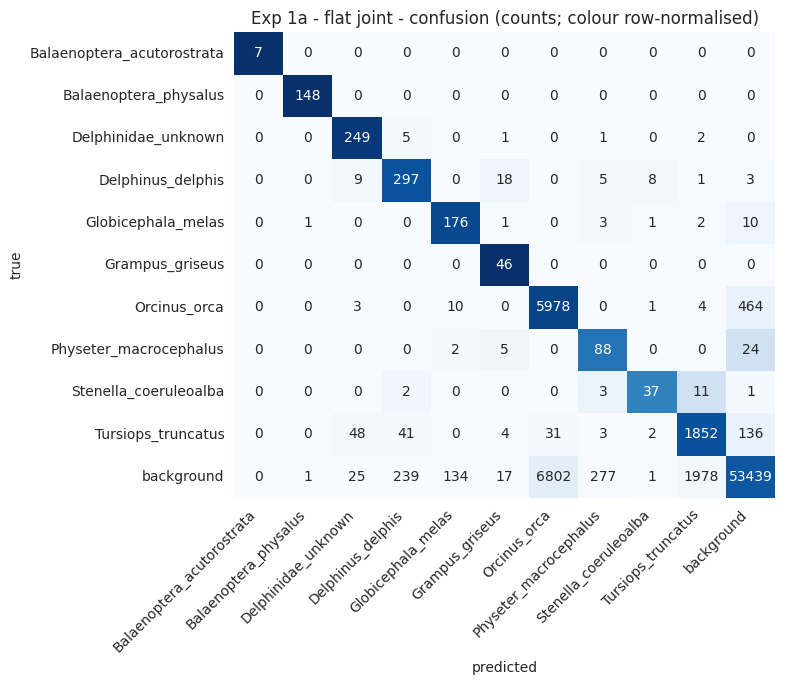

In [20]:
# ============================================================
# Exp 1a - flat joint
# ============================================================
def fit_joint(meta_tr, meta_va, meta_te, label_col, min_train_per_class=5,
              verbose=True):
    counts = meta_tr[label_col].value_counts()
    keep = set(counts[counts >= min_train_per_class].index)
    if verbose:
        dropped = set(counts.index) - keep
        if dropped:
            print(f"  dropping classes <{min_train_per_class} in train: {sorted(dropped)}")
    meta_tr = meta_tr[meta_tr[label_col].isin(keep)].copy()
    meta_va = meta_va[meta_va[label_col].isin(keep)].copy()
    meta_te = meta_te[meta_te[label_col].isin(keep)].copy()
    le = LabelEncoder().fit(sorted(keep))
    for d in (meta_tr, meta_va, meta_te):
        d['y'] = le.transform(d[label_col].astype(str))
    Xtr = np.asarray(X_all[meta_tr['row'].values], dtype=np.float32)
    Xva = np.asarray(X_all[meta_va['row'].values], dtype=np.float32)
    Xte = np.asarray(X_all[meta_te['row'].values], dtype=np.float32)
    if verbose:
        print(f"  fit_joint: train={len(meta_tr):,} val={len(meta_va):,} test={len(meta_te):,} classes={len(le.classes_)}")
    r = train_eval_mlp(Xtr, meta_tr['y'].values, Xva, meta_va['y'].values,
                       Xte, meta_te['y'].values, n_classes=len(le.classes_),
                       class_names=list(le.classes_), verbose=False)
    r['classes']      = list(le.classes_)
    r['meta_te']      = meta_te.reset_index(drop=True)
    r['rows_te']      = meta_te['row'].values
    r['label_encoder']= le
    return r


print("=== Experiment 1a - flat joint classifier ===")
exp1a = fit_joint(exp1_meta_tr, exp1_meta_va, exp1_meta_te, 'label_joint',
                  verbose=True)
report_run("Exp 1a - flat joint", exp1a)


=== Experiment 1b.i - binary mammal/non_mammal detector ===
  fit_joint: train=122,327 val=52,230 test=72,657 classes=2

  Exp 1b.i - detector (binary)
  val_macro_f1               = 0.819
  test_macro_f1 (test-only)  = 0.835
  test_macro_f1 (full vocab) = 0.835
  test_weighted_f1           = 0.919
  test_accuracy              = 0.915
  test_balanced_acc          = 0.876
  trained in 41.9s

  test set contains 2 / 2 classes: ['mammal', 'non_mammal']

              precision    recall  f1-score   support

      mammal      0.641     0.823     0.721      9744
  non_mammal      0.971     0.929     0.950     62913

    accuracy                          0.915     72657
   macro avg      0.806     0.876     0.835     72657
weighted avg      0.927     0.915     0.919     72657



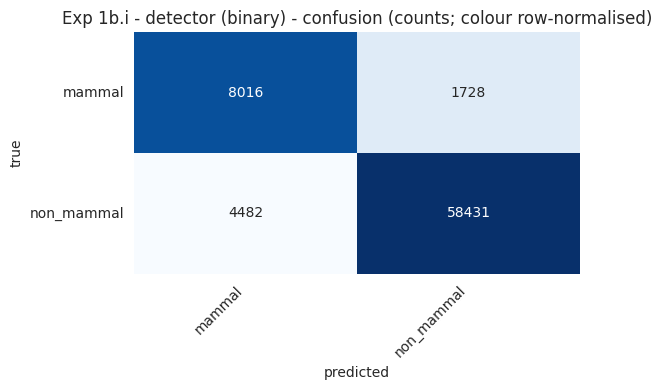


  detector flags 12,498/72,657 test rows as mammal


In [ ]:
# ============================================================
# Exp 1b - hierarchical cascade
# ============================================================
NON_MAMMAL_JOINT = 'background'   # only non-mammal class in our joint label

# ----- 1b.i  binary detector: mammal vs non-mammal -----
def to_binary(label): return 'mammal' if label != NON_MAMMAL_JOINT else 'non_mammal'

tr_b = exp1_meta_tr.assign(label_bin=exp1_meta_tr['label_joint'].map(to_binary))
va_b = exp1_meta_va.assign(label_bin=exp1_meta_va['label_joint'].map(to_binary))
te_b = exp1_meta_te.assign(label_bin=exp1_meta_te['label_joint'].map(to_binary))

print("=== Experiment 1b.i - binary mammal/non_mammal detector ===")
det = fit_joint(tr_b, va_b, te_b, 'label_bin',
                min_train_per_class=5, verbose=True)
report_run("Exp 1b.i - detector (binary)", det)

# Predicted "mammal" mask on the test set
mammal_class_idx = det['classes'].index('mammal')
det_pred_mammal = (det['ypr'] == mammal_class_idx)
print(f"\n  detector flags {det_pred_mammal.sum():,}/{len(det['ypr']):,} test rows as mammal")


=== Experiment 1b.ii - species head (mammal-only training) ===
  fit_joint: train=15,911 val=7,953 test=9,744 classes=10

  Exp 1b.ii - species head (oracle: true mammal rows)
  val_macro_f1               = 0.862
  test_macro_f1 (test-only)  = 0.880
  test_macro_f1 (full vocab) = 0.880
  test_weighted_f1           = 0.961
  test_accuracy              = 0.960
  test_balanced_acc          = 0.924
  trained in 5.3s

  test set contains 10 / 10 classes: ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus']

                            precision    recall  f1-score   support

Balaenoptera_acutorostrata      1.000     1.000     1.000         7
     Balaenoptera_physalus      0.987     1.000     0.993       148
       Delphinidae_unknown      0.739     0.953     0.832       258
         Delphinus_delphis      0.839     

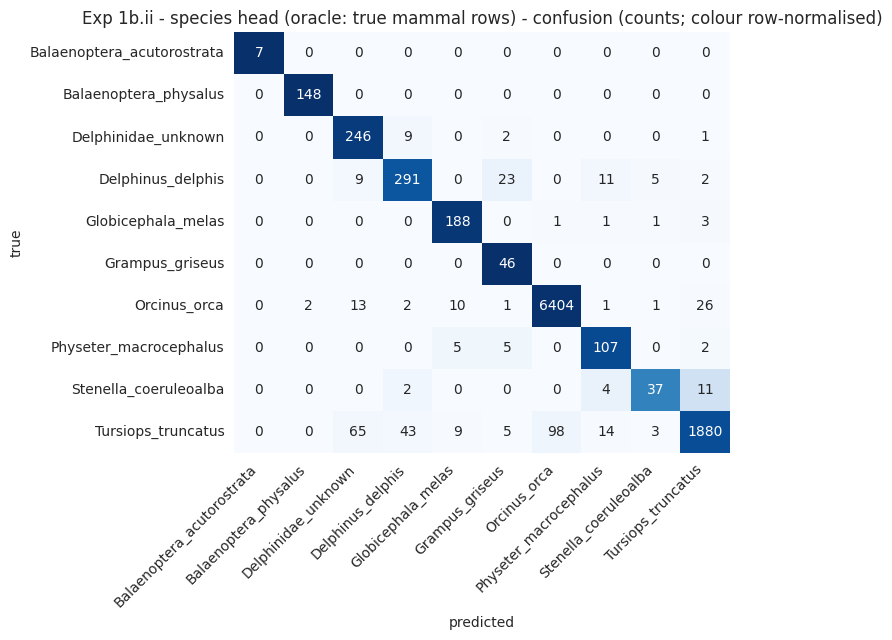

In [23]:
# ----- 1b.ii  species head: trained on mammal rows only -----
SPECIES_TIER = 'label_t4'
mammal_tr = exp1_meta_tr.dropna(subset=[SPECIES_TIER]).copy()
mammal_va = exp1_meta_va.dropna(subset=[SPECIES_TIER]).copy()
mammal_te = exp1_meta_te.dropna(subset=[SPECIES_TIER]).copy()

print("=== Experiment 1b.ii - species head (mammal-only training) ===")
sp_head = fit_joint(mammal_tr, mammal_va, mammal_te, SPECIES_TIER,
                    min_train_per_class=5, verbose=True)
report_run("Exp 1b.ii - species head (oracle: true mammal rows)", sp_head)



  Exp 1b - hierarchical cascade (joint vocabulary)
  val_macro_f1               = nan
  test_macro_f1 (test-only)  = 0.736
  test_macro_f1 (full vocab) = 0.736
  test_weighted_f1           = 0.916
  test_accuracy              = 0.911
  test_balanced_acc          = 0.812
  trained in 47.2s

  test set contains 11 / 11 classes: ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']

                            precision    recall  f1-score   support

Balaenoptera_acutorostrata      0.800     0.571     0.667         7
     Balaenoptera_physalus      0.961     1.000     0.980       148
       Delphinidae_unknown      0.767     0.946     0.847       258
         Delphinus_delphis      0.597     0.815     0.689       341
        Globicephala_melas      0.664     0.866     0.752       194
           Grampu

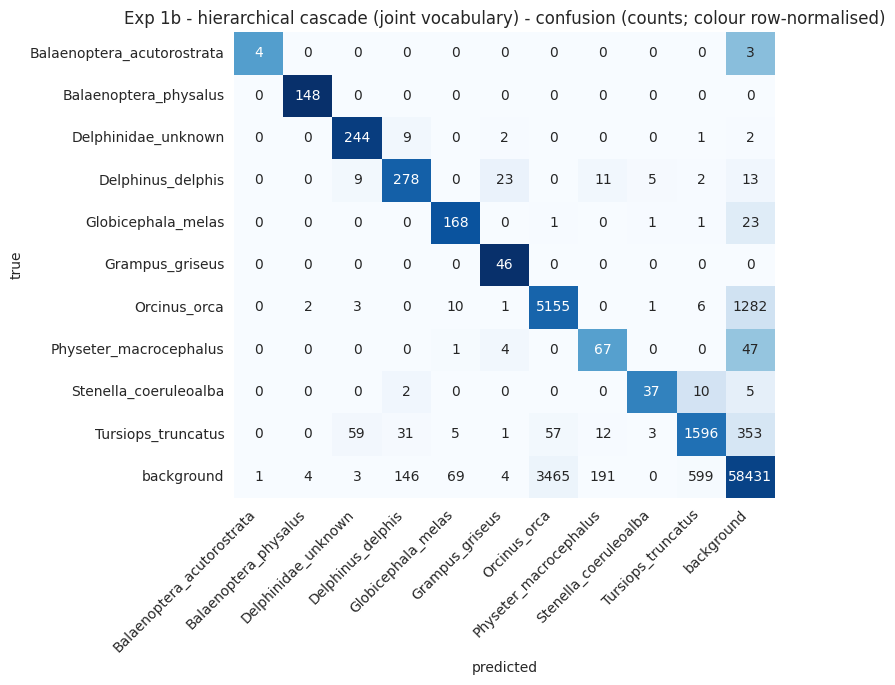

In [24]:
# ============================================================
# 1b cascade - detector predictions feed the species head
# ============================================================
# Build the cascade prediction on the FULL exp1 test set, then compute joint metrics
# directly comparable to exp1a.

joint_classes = exp1a['classes']
joint_to_idx = {c: i for i, c in enumerate(joint_classes)}
sp_classes = sp_head['classes']

# Score the full exp1 test set with the species head (use its scaler)
Xte_full = np.asarray(X_all[exp1_meta_te['row'].values], dtype=np.float32)
Xte_for_sp = sp_head['scaler'].transform(Xte_full).astype(np.float32)
logits_sp_full = predict_mlp(sp_head['model'], Xte_for_sp)
ypr_sp_full_local = logits_sp_full.argmax(1)
ypr_sp_full_joint = np.array([joint_to_idx[sp_classes[i]] for i in ypr_sp_full_local])

# Cascade rule: detector says non-mammal -> 'background'; mammal -> species head
bg_idx_in_joint = joint_to_idx[NON_MAMMAL_JOINT]
ypr_cascade_joint = np.where(det_pred_mammal, ypr_sp_full_joint, bg_idx_in_joint)

# Ground truth in the joint vocabulary
yte_full_joint = np.array(
    [joint_to_idx[c] for c in exp1_meta_te['label_joint'].astype(str).values])

cascade_res = {
    'yte': yte_full_joint,
    'ypr': ypr_cascade_joint,
    'logits_te': None,
    'val_macro_f1':              float('nan'),
    'test_macro_f1':             float(f1_score(yte_full_joint, ypr_cascade_joint,
                                                average='macro',
                                                labels=sorted(np.unique(yte_full_joint).tolist()),
                                                zero_division=0)),
    'test_macro_f1_full_vocab':  float(f1_score(yte_full_joint, ypr_cascade_joint,
                                                average='macro',
                                                labels=list(range(len(joint_classes))),
                                                zero_division=0)),
    'test_weighted_f1':          float(f1_score(yte_full_joint, ypr_cascade_joint,
                                                average='weighted',
                                                labels=sorted(np.unique(yte_full_joint).tolist()),
                                                zero_division=0)),
    'test_accuracy':             float(accuracy_score(yte_full_joint, ypr_cascade_joint)),
    'test_balanced_acc':         float(balanced_accuracy_score(yte_full_joint, ypr_cascade_joint)),
    'elapsed_s':                 det['elapsed_s'] + sp_head['elapsed_s'],
    'class_names':               joint_classes,
    'test_classes_present':      sorted(np.unique(yte_full_joint).tolist()),
}
report_run("Exp 1b - hierarchical cascade (joint vocabulary)", cascade_res)


In [25]:
# Cross-comparison table for Experiment 1
exp1_rows = [
    {'variant': '1a flat joint',
     'val_macro_f1':              exp1a['val_macro_f1'],
     'test_macro_f1 (test-only)': exp1a['test_macro_f1'],
     'test_macro_f1 (full vocab)':exp1a['test_macro_f1_full_vocab'],
     'test_weighted_f1':          exp1a['test_weighted_f1'],
     'test_accuracy':             exp1a['test_accuracy'],
     'test_balanced_acc':         exp1a['test_balanced_acc']},
    {'variant': '1b.i detector (binary)',
     'val_macro_f1':              det['val_macro_f1'],
     'test_macro_f1 (test-only)': det['test_macro_f1'],
     'test_macro_f1 (full vocab)':det['test_macro_f1_full_vocab'],
     'test_weighted_f1':          det['test_weighted_f1'],
     'test_accuracy':             det['test_accuracy'],
     'test_balanced_acc':         det['test_balanced_acc']},
    {'variant': '1b.ii species head (oracle)',
     'val_macro_f1':              sp_head['val_macro_f1'],
     'test_macro_f1 (test-only)': sp_head['test_macro_f1'],
     'test_macro_f1 (full vocab)':sp_head['test_macro_f1_full_vocab'],
     'test_weighted_f1':          sp_head['test_weighted_f1'],
     'test_accuracy':             sp_head['test_accuracy'],
     'test_balanced_acc':         sp_head['test_balanced_acc']},
    {'variant': '1b cascade (realistic)',
     'val_macro_f1':              float('nan'),
     'test_macro_f1 (test-only)': cascade_res['test_macro_f1'],
     'test_macro_f1 (full vocab)':cascade_res['test_macro_f1_full_vocab'],
     'test_weighted_f1':          cascade_res['test_weighted_f1'],
     'test_accuracy':             cascade_res['test_accuracy'],
     'test_balanced_acc':         cascade_res['test_balanced_acc']},
]
summary_exp1 = pd.DataFrame(exp1_rows)
print(summary_exp1.to_string(index=False))
summary_exp1.to_csv(OUT_DIR / 'exp1_joint_vs_hierarchical.csv', index=False)


                    variant  val_macro_f1  test_macro_f1 (test-only)  test_macro_f1 (full vocab)  test_weighted_f1  test_accuracy  test_balanced_acc
              1a flat joint      0.710873                   0.731316                    0.731316          0.875766       0.857687           0.892509
     1b.i detector (binary)      0.819291                   0.835170                    0.835170          0.918865       0.914530           0.875709
1b.ii species head (oracle)      0.861867                   0.880020                    0.880020          0.960662       0.959975           0.923966
     1b cascade (realistic)           NaN                   0.735837                    0.735837          0.916084       0.910773           0.811568


## 4. Experiment 2 - joint LODO across 11 datasets

For each held-out dataset in `JOINT_LODO_HOLDOUTS`, train the joint classifier
on every *other* dataset (including WATKINS) and evaluate on the held-out one.

**WATKINS is intentionally not in the holdout list** - it's the only dataset
with most of the rare species (`Balaenoptera_physalus`, `Balaenoptera_acutorostrata`,
heavy `Physeter_macrocephalus`), so it's most useful as training data than as a
test fold for the joint task.

Per-fold metric set:
- `test_macro_f1` - averaged over classes present in the held-out test set.
- `test_macro_f1_full_vocab` - averaged over all training classes (zero classes
  pull this down; useful as a strict reading).
- `test_accuracy`, `test_balanced_acc` - averaging-scheme-independent.
- species-restricted: macro-F1 over mammal-true-label test rows only. This is
  the apples-to-apples number to compare against Experiment 3.

Per-fold log prints the test-set class composition before training so anomalies
(e.g. a fold with no background rows in test) are visible up front.


In [10]:
JOINT_LODO_HOLDOUTS = [
    'OLTREMARE', 'MONISH', 'FREMANTLE',
    'ECOSS_testtrain', 'ECOSS_enhanced', 'ECOSS_annot',
    'DRYAD', 'DOLPHINFREE', 'DCLDE_2026',
    'Adriatic_Sea', 'ALNITAK_CAVANILLES',
]
assert set(JOINT_LODO_HOLDOUTS).issubset(set(meta_joint['dataset'].unique())), \
    "some hold-out dataset names don't appear in the corpus - check spelling"

print(f"joint-LODO hold-out folds ({len(JOINT_LODO_HOLDOUTS)}):")
for d in JOINT_LODO_HOLDOUTS:
    n = (meta_joint['dataset'] == d).sum()
    print(f"  {d:22s}  n_joint_rows = {n:,}")
print(f"\nWATKINS stays in training: {(meta_joint['dataset'] == 'WATKINS').sum():,} rows")


joint-LODO hold-out folds (11):
  OLTREMARE               n_joint_rows = 16,860
  MONISH                  n_joint_rows = 617
  FREMANTLE               n_joint_rows = 332
  ECOSS_testtrain         n_joint_rows = 36,044
  ECOSS_enhanced          n_joint_rows = 168
  ECOSS_annot             n_joint_rows = 752
  DRYAD                   n_joint_rows = 6,770
  DOLPHINFREE             n_joint_rows = 3,290
  DCLDE_2026              n_joint_rows = 174,538
  Adriatic_Sea            n_joint_rows = 1,180
  ALNITAK_CAVANILLES      n_joint_rows = 4,786

WATKINS stays in training: 1,877 rows


In [31]:
def run_joint_lodo(held_out, min_train_per_class=5, verbose=True):
    train_meta = meta_joint[meta_joint['dataset'] != held_out].copy()
    test_meta  = meta_joint[meta_joint['dataset'] == held_out].copy()

    # ----- choose class set -----
    counts = train_meta['label_joint'].value_counts()
    train_keep = set(counts[counts >= min_train_per_class].index)
    train_classes_all = set(train_meta['label_joint'].unique())
    dropped_train = train_classes_all - train_keep

    test_classes_all = set(test_meta['label_joint'].unique())
    test_keep = test_classes_all & train_keep
    test_dropped = test_classes_all - train_keep

    if verbose:
        print(f"\n  [{held_out}] training classes ({len(train_keep)}): {sorted(train_keep)}")
        if dropped_train:
            print(f"  [{held_out}] training classes dropped (<{min_train_per_class} rows): {sorted(dropped_train)}")
        print(f"  [{held_out}] test-set class composition:")
        for c, n in test_meta['label_joint'].value_counts().items():
            in_train = 'present in training' if c in train_keep else 'NOT in training pool'
            print(f"      {c:32s} n={n:>6d}  ({in_train})")
        if test_dropped:
            print(f"  [{held_out}] dropping test rows for un-trainable classes: {sorted(test_dropped)}")

    if len(train_keep) < 2:
        print(f"  [{held_out}] only {len(train_keep)} trainable class(es) - skipping")
        return None
    if len(test_keep) < 1:
        print(f"  [{held_out}] zero held-out classes are in the training pool - skipping")
        return None

    train_meta = train_meta[train_meta['label_joint'].isin(train_keep)].copy()
    test_meta  = test_meta [test_meta ['label_joint'].isin(test_keep )].copy()

    le = LabelEncoder().fit(sorted(train_keep))
    train_meta = train_meta.assign(y=le.transform(train_meta['label_joint'].astype(str)))
    test_meta  = test_meta .assign(y=le.transform(test_meta ['label_joint'].astype(str)))

    tr_pos, va_pos = split_train_val(train_meta, val_size=0.1, random_state=42)
    rows_tr = train_meta.iloc[tr_pos]['row'].values
    rows_va = train_meta.iloc[va_pos]['row'].values
    rows_te = test_meta['row'].values
    Xtr = np.asarray(X_all[rows_tr], dtype=np.float32)
    Xva = np.asarray(X_all[rows_va], dtype=np.float32)
    Xte = np.asarray(X_all[rows_te], dtype=np.float32)
    ytr = train_meta.iloc[tr_pos]['y'].values
    yva = train_meta.iloc[va_pos]['y'].values
    yte = test_meta['y'].values

    if verbose:
        print(f"  [{held_out}] train={len(rows_tr):,}  val={len(rows_va):,}  test={len(rows_te):,}")

    r = train_eval_mlp(Xtr, ytr, Xva, yva, Xte, yte,
                       n_classes=len(le.classes_),
                       class_names=list(le.classes_), verbose=False)

    # Species-restricted metrics: subset test rows to mammal true labels
    sp_class_ix = [i for i, c in enumerate(le.classes_) if c != NON_MAMMAL_JOINT]
    sp_mask = np.isin(yte, sp_class_ix)
    if sp_mask.sum() > 0:
        sp_present = sorted(np.unique(yte[sp_mask]).tolist())
        bg_idx_local = (le.transform([NON_MAMMAL_JOINT])[0]
                        if NON_MAMMAL_JOINT in le.classes_ else -1)
        sp_routed_to_bg = float((r['ypr'][sp_mask] == bg_idx_local).mean()) \
                         if bg_idx_local >= 0 else 0.0
        r['sp_n_test_rows']      = int(sp_mask.sum())
        r['sp_n_classes_present']= len(sp_present)
        r['sp_macro_f1']         = float(f1_score(yte[sp_mask], r['ypr'][sp_mask],
                                                  average='macro', labels=sp_present,
                                                  zero_division=0))
        r['sp_balanced_acc']     = float(balanced_accuracy_score(yte[sp_mask],
                                                                 r['ypr'][sp_mask]))
        r['sp_frac_routed_to_bg']= sp_routed_to_bg
    else:
        r['sp_n_test_rows'] = 0
        r['sp_n_classes_present'] = 0
        r['sp_macro_f1'] = None
        r['sp_balanced_acc'] = None
        r['sp_frac_routed_to_bg'] = None

    r['held_out']        = held_out
    r['rows_te']         = rows_te
    r['classes']         = list(le.classes_)
    r['n_train']         = len(rows_tr)
    r['n_val']           = len(rows_va)
    r['n_test']          = len(rows_te)
    r['n_train_classes'] = len(le.classes_)
    return r


In [ ]:
results_joint_lodo = {}
for ds in tqdm(JOINT_LODO_HOLDOUTS, desc='joint-LODO'):
    r = run_joint_lodo(ds, verbose=True)
    if r is not None:
        results_joint_lodo[ds] = r

rows = []
for ds, r in results_joint_lodo.items():
    rows.append({
        'held_out':                  ds,
        'n_train':                   r['n_train'],
        'n_test':                    r['n_test'],
        'n_train_classes':           r['n_train_classes'],
        'n_test_classes':            len(r['test_classes_present']),
        'val_macro_f1':              r['val_macro_f1'],
        'test_macro_f1 (test-only)': r['test_macro_f1'],
        'test_macro_f1 (full vocab)':r['test_macro_f1_full_vocab'],
        'test_weighted_f1':          r['test_weighted_f1'],
        'test_accuracy':             r['test_accuracy'],
        'test_balanced_acc':         r['test_balanced_acc'],
        'sp_n_rows':                 r['sp_n_test_rows'],
        'sp_n_classes':              r['sp_n_classes_present'],
        'sp_macro_f1':               r['sp_macro_f1'],
        'sp_balanced_acc':           r['sp_balanced_acc'],
        'sp_frac_routed_to_bg':      r['sp_frac_routed_to_bg'],
    })
summary_exp2 = pd.DataFrame(rows).sort_values('test_macro_f1 (test-only)', ascending=False)
print()
print(summary_exp2.to_string(index=False))
summary_exp2.to_csv(OUT_DIR / 'exp2_joint_lodo_summary.csv', index=False)


joint-LODO:   0%|          | 0/11 [00:00<?, ?it/s]


  [OLTREMARE] training classes (11): ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  [OLTREMARE] test-set class composition:
      background                       n= 13956  (present in training)
      Tursiops_truncatus               n=  2904  (present in training)
  [OLTREMARE] train=207,861  val=22,493  test=16,860

  [MONISH] training classes (11): ['Balaenoptera_acutorostrata', 'Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']
  [MONISH] test-set class composition:
      Globicephala_melas               n=   410  (present in training)
      Grampus_griseus                  n=   113  (present in training)
      Orcinus_orca   


  Exp 2 - joint LODO held out: OLTREMARE
  val_macro_f1               = 0.790
  test_macro_f1 (test-only)  = 0.830
  test_macro_f1 (full vocab) = 0.151
  test_weighted_f1           = 0.903
  test_accuracy              = 0.901
  test_balanced_acc          = 0.810
  trained in 51.5s

  test set contains 2 / 11 classes: ['Tursiops_truncatus', 'background']

                    precision    recall  f1-score   support

Tursiops_truncatus      0.771     0.672     0.718      2904
        background      0.935     0.949     0.942     13956

         micro avg      0.910     0.901     0.906     16860
         macro avg      0.853     0.810     0.830     16860
      weighted avg      0.907     0.901     0.903     16860



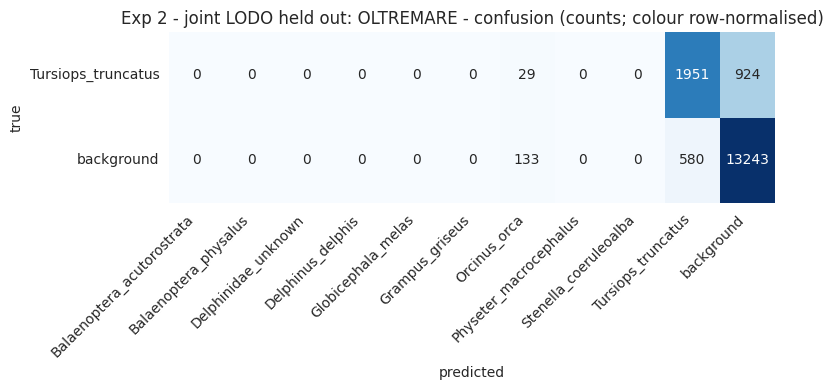


  Exp 2 - joint LODO held out: MONISH
  val_macro_f1               = 0.688
  test_macro_f1 (test-only)  = 0.075
  test_macro_f1 (full vocab) = 0.034
  test_weighted_f1           = 0.070
  test_accuracy              = 0.075
  test_balanced_acc          = 0.158
  trained in 64.8s

  test set contains 5 / 11 classes: ['Balaenoptera_physalus', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Tursiops_truncatus']

                       precision    recall  f1-score   support

Balaenoptera_physalus      0.000     0.000     0.000        29
   Globicephala_melas      0.174     0.020     0.035       410
      Grampus_griseus      0.700     0.124     0.211       113
         Orcinus_orca      0.073     0.649     0.130        37
   Tursiops_truncatus      0.000     0.000     0.000        28

            micro avg      0.116     0.075     0.091       617
            macro avg      0.189     0.158     0.075       617
         weighted avg      0.248     0.075     0.070       617



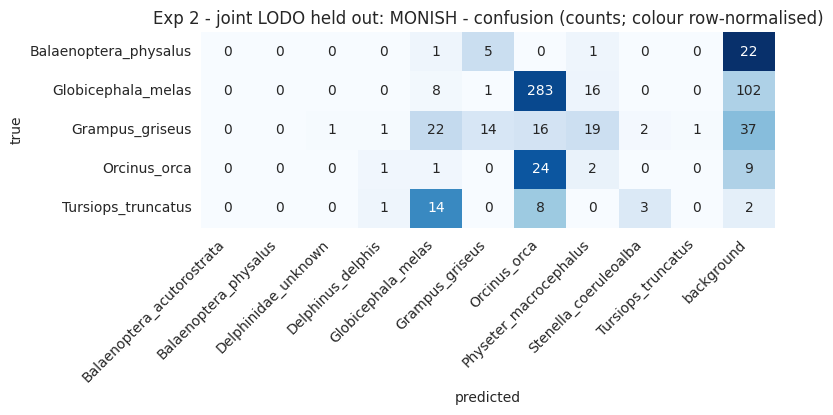


  Exp 2 - joint LODO held out: FREMANTLE
  val_macro_f1               = 0.716
  test_macro_f1 (test-only)  = 0.494
  test_macro_f1 (full vocab) = 0.045
  test_weighted_f1           = 0.494
  test_accuracy              = 0.328
  test_balanced_acc          = 0.328
  trained in 64.1s

  test set contains 1 / 11 classes: ['Tursiops_truncatus']

                    precision    recall  f1-score   support

Tursiops_truncatus      1.000     0.328     0.494       332

         micro avg      1.000     0.328     0.494       332
         macro avg      1.000     0.328     0.494       332
      weighted avg      1.000     0.328     0.494       332



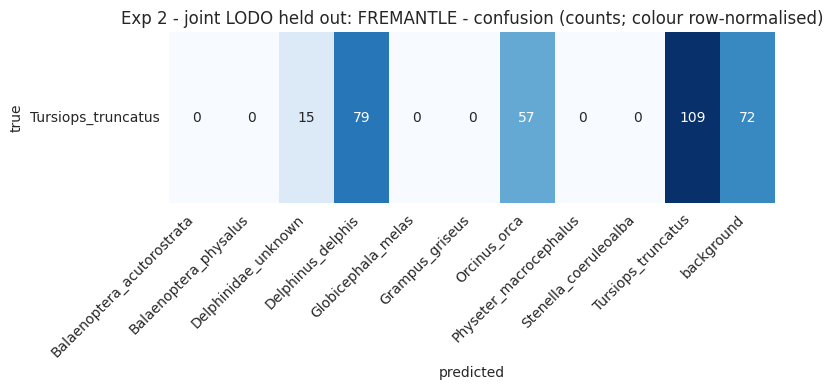


  Exp 2 - joint LODO held out: ECOSS_testtrain
  val_macro_f1               = 0.786
  test_macro_f1 (test-only)  = 0.222
  test_macro_f1 (full vocab) = 0.121
  test_weighted_f1           = 0.968
  test_accuracy              = 0.942
  test_balanced_acc          = 0.606
  trained in 44.2s

  test set contains 6 / 11 classes: ['Delphinus_delphis', 'Globicephala_melas', 'Orcinus_orca', 'Physeter_macrocephalus', 'Tursiops_truncatus', 'background']

                        precision    recall  f1-score   support

     Delphinus_delphis      0.000     0.000     0.000        40
    Globicephala_melas      0.004     0.077     0.008        26
          Orcinus_orca      0.077     0.818     0.141        22
Physeter_macrocephalus      0.058     0.850     0.108        20
    Tursiops_truncatus      0.056     0.947     0.105        19
            background      1.000     0.944     0.971     35917

             micro avg      0.954     0.942     0.948     36044
             macro avg      0.199    

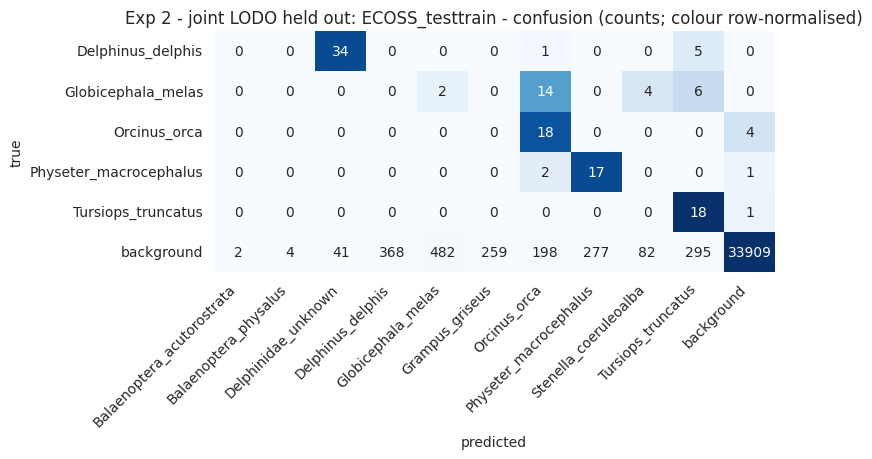


  Exp 2 - joint LODO held out: ECOSS_enhanced
  val_macro_f1               = 0.715
  test_macro_f1 (test-only)  = 0.493
  test_macro_f1 (full vocab) = 0.269
  test_weighted_f1           = 0.345
  test_accuracy              = 0.327
  test_balanced_acc          = 0.474
  trained in 38.6s

  test set contains 6 / 11 classes: ['Delphinidae_unknown', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']

                        precision    recall  f1-score   support

   Delphinidae_unknown      0.000     0.000     0.000        42
          Orcinus_orca      1.000     0.800     0.889        15
Physeter_macrocephalus      0.833     1.000     0.909        15
 Stenella_coeruleoalba      0.000     0.000     0.000        44
    Tursiops_truncatus      1.000     0.926     0.962        27
            background      0.600     0.120     0.200        25

             micro avg      0.917     0.327     0.482       168
             macro avg      0.572

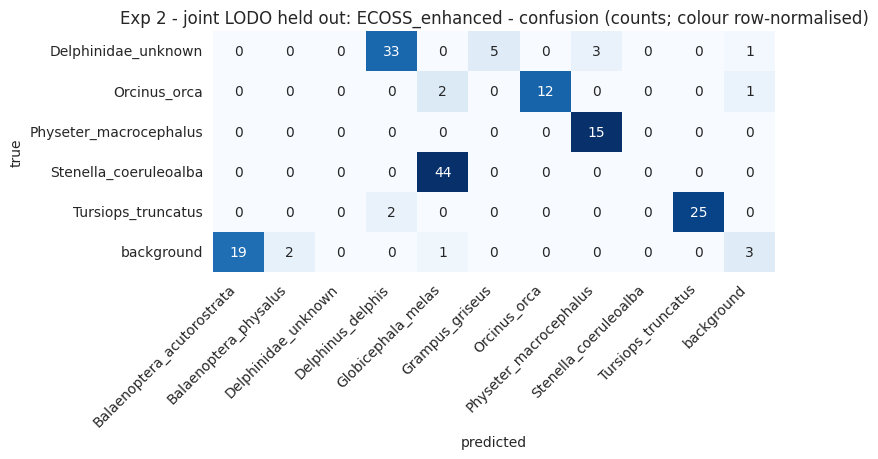


  Exp 2 - joint LODO held out: ECOSS_annot
  val_macro_f1               = 0.552
  test_macro_f1 (test-only)  = 0.312
  test_macro_f1 (full vocab) = 0.057
  test_weighted_f1           = 0.238
  test_accuracy              = 0.285
  test_balanced_acc          = 0.374
  trained in 39.2s

  test set contains 2 / 11 classes: ['Delphinidae_unknown', 'background']

                     precision    recall  f1-score   support

Delphinidae_unknown      0.000     0.000     0.000       466
         background      0.536     0.748     0.625       286

          micro avg      0.536     0.285     0.372       752
          macro avg      0.268     0.374     0.312       752
       weighted avg      0.204     0.285     0.238       752



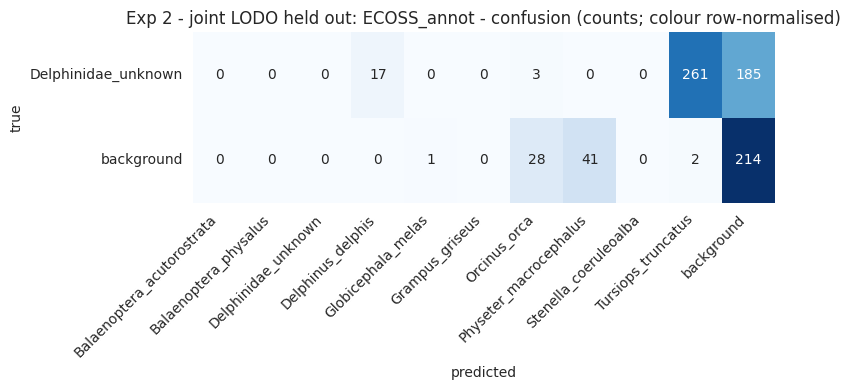


  Exp 2 - joint LODO held out: DRYAD
  val_macro_f1               = 0.741
  test_macro_f1 (test-only)  = 0.710
  test_macro_f1 (full vocab) = 0.129
  test_weighted_f1           = 0.717
  test_accuracy              = 0.657
  test_balanced_acc          = 0.653
  trained in 30.6s

  test set contains 2 / 11 classes: ['Tursiops_truncatus', 'background']

                    precision    recall  f1-score   support

Tursiops_truncatus      0.697     0.625     0.659      2916
        background      0.864     0.681     0.761      3854

         micro avg      0.787     0.657     0.716      6770
         macro avg      0.781     0.653     0.710      6770
      weighted avg      0.792     0.657     0.717      6770



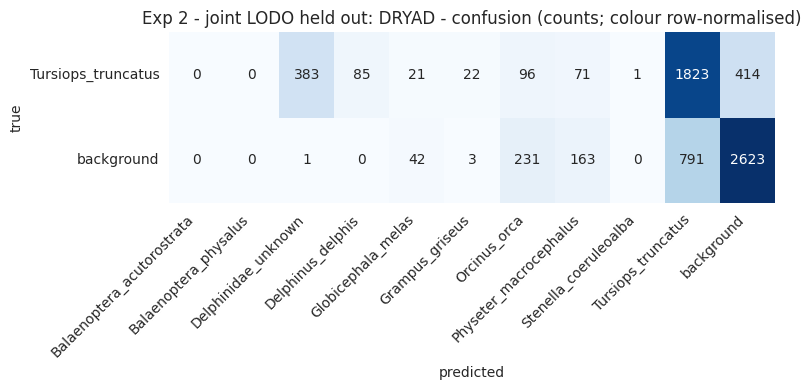


  Exp 2 - joint LODO held out: DOLPHINFREE
  val_macro_f1               = 0.630
  test_macro_f1 (test-only)  = 0.403
  test_macro_f1 (full vocab) = 0.073
  test_weighted_f1           = 0.464
  test_accuracy              = 0.329
  test_balanced_acc          = 0.279
  trained in 26.6s

  test set contains 2 / 11 classes: ['Delphinus_delphis', 'background']

                   precision    recall  f1-score   support

Delphinus_delphis      0.858     0.116     0.204      1150
       background      0.944     0.443     0.603      2140

        micro avg      0.933     0.329     0.486      3290
        macro avg      0.901     0.279     0.403      3290
     weighted avg      0.914     0.329     0.464      3290



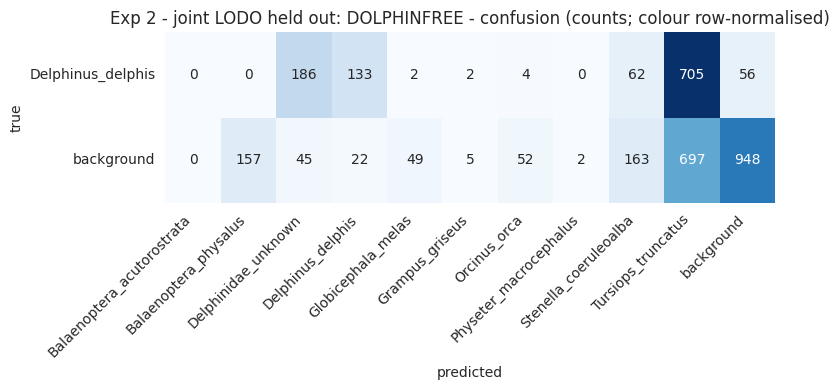


  Exp 2 - joint LODO held out: DCLDE_2026
  val_macro_f1               = 0.842
  test_macro_f1 (test-only)  = 0.471
  test_macro_f1 (full vocab) = 0.086
  test_weighted_f1           = 0.640
  test_accuracy              = 0.511
  test_balanced_acc          = 0.362
  trained in 15.1s

  test set contains 2 / 11 classes: ['Orcinus_orca', 'background']

              precision    recall  f1-score   support

Orcinus_orca      0.486     0.165     0.246     21696
  background      0.921     0.560     0.696    152842

   micro avg      0.889     0.511     0.649    174538
   macro avg      0.704     0.362     0.471    174538
weighted avg      0.867     0.511     0.640    174538



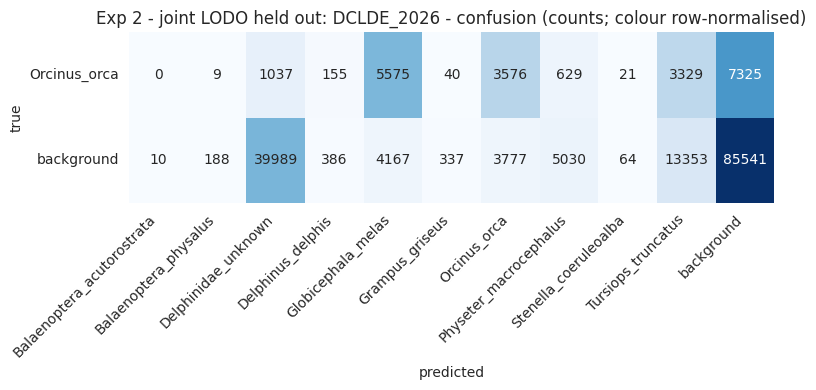


  Exp 2 - joint LODO held out: Adriatic_Sea
  val_macro_f1               = 0.693
  test_macro_f1 (test-only)  = 0.675
  test_macro_f1 (full vocab) = 0.123
  test_weighted_f1           = 0.700
  test_accuracy              = 0.636
  test_balanced_acc          = 0.736
  trained in 25.7s

  test set contains 2 / 11 classes: ['Tursiops_truncatus', 'background']

                    precision    recall  f1-score   support

Tursiops_truncatus      0.971     0.568     0.717       942
        background      0.489     0.903     0.634       238

         micro avg      0.757     0.636     0.691      1180
         macro avg      0.730     0.736     0.675      1180
      weighted avg      0.874     0.636     0.700      1180



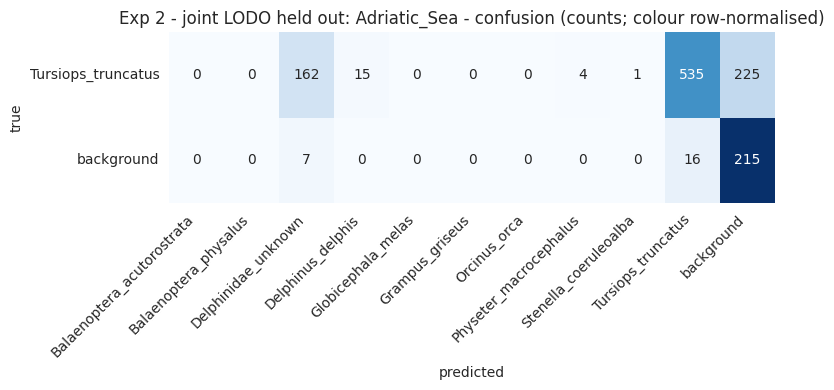


  Exp 2 - joint LODO held out: ALNITAK_CAVANILLES
  val_macro_f1               = 0.850
  test_macro_f1 (test-only)  = 0.171
  test_macro_f1 (full vocab) = 0.093
  test_weighted_f1           = 0.861
  test_accuracy              = 0.886
  test_balanced_acc          = 0.170
  trained in 40.3s

  test set contains 6 / 11 classes: ['Globicephala_melas', 'Grampus_griseus', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus', 'background']

                        precision    recall  f1-score   support

    Globicephala_melas      1.000     0.007     0.014       141
       Grampus_griseus      0.000     0.000     0.000        45
Physeter_macrocephalus      0.212     0.039     0.066       179
 Stenella_coeruleoalba      0.000     0.000     0.000        15
    Tursiops_truncatus      0.000     0.000     0.000        58
            background      0.916     0.974     0.944      4348

             micro avg      0.905     0.886     0.896      4786
             macro avg     

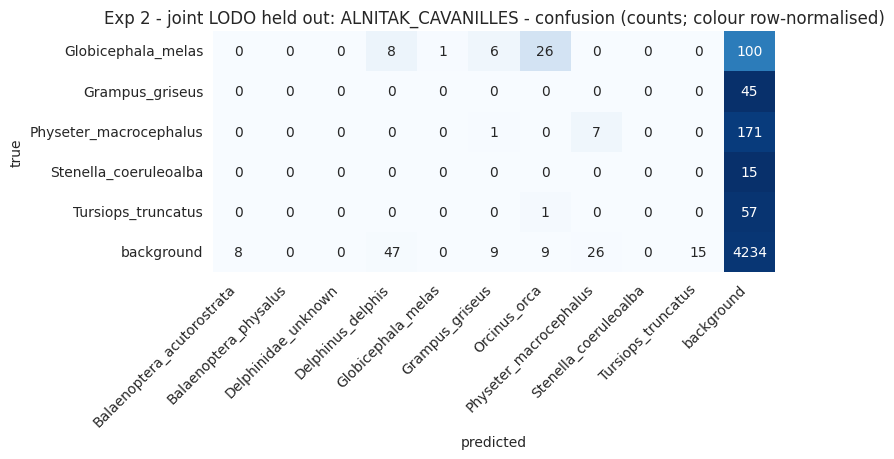

In [33]:
# Per-fold detailed reports
for ds, r in results_joint_lodo.items():
    report_run(f"Exp 2 - joint LODO held out: {ds}", r, max_classes_cm=20)


## 5. Experiment 3 - pure species LODO (no background)

Mammal-only rows, species classification. Held-out folds restricted to the four
datasets where the cross-dataset species support justifies a LODO test:
WATKINS, MONISH, ECOSS_testtrain, ALNITAK_CAVANILLES. WATKINS additionally has
`Balaenoptera_acutorostrata` removed from its eligible classes (only 17 rows
total, none in any other dataset -> un-transferable).

For each fold, the training class set is the species the model has seen in at
least one other dataset with `>= min_train_per_class` rows. The test class set
is the intersection of (held-out species) ∩ (training class set).


In [35]:
SPECIES_LODO_HOLDOUTS = ['WATKINS', 'MONISH', 'ECOSS_testtrain', 'ALNITAK_CAVANILLES']
SPECIES_LODO_EXCLUDE = {
    # held_out_dataset -> set of species to drop from BOTH train and test of this fold
    'WATKINS': {'Balaenoptera_acutorostrata'},
}

# Mammal-only frame
sp_meta_full = meta_all.dropna(subset=[SPECIES_TIER]).copy()
print(f"species-labelled rows: {len(sp_meta_full):,}")
print(f"unique species:        {sp_meta_full[SPECIES_TIER].nunique()}")


species-labelled rows: 33,608
unique species:        10


In [36]:
def run_species_lodo(held_out, min_train_per_class=5, verbose=True):
    exclude = SPECIES_LODO_EXCLUDE.get(held_out, set())
    train_meta = sp_meta_full[sp_meta_full['dataset'] != held_out].copy()
    test_meta  = sp_meta_full[sp_meta_full['dataset'] == held_out].copy()

    if exclude:
        before_tr = len(train_meta); before_te = len(test_meta)
        train_meta = train_meta[~train_meta[SPECIES_TIER].isin(exclude)].copy()
        test_meta  = test_meta [~test_meta [SPECIES_TIER].isin(exclude)].copy()
        if verbose:
            print(f"  [{held_out}] excluding species {sorted(exclude)}: "
                  f"train {before_tr}->{len(train_meta)}, test {before_te}->{len(test_meta)}")

    counts = train_meta[SPECIES_TIER].value_counts()
    train_keep = set(counts[counts >= min_train_per_class].index)
    test_classes_all = set(test_meta[SPECIES_TIER].unique())
    test_keep = test_classes_all & train_keep
    test_dropped = test_classes_all - train_keep

    if verbose:
        print(f"\n  [{held_out}] training over {len(train_keep)} species: {sorted(train_keep)}")
        print(f"  [{held_out}] test-set species composition:")
        for c, n in test_meta[SPECIES_TIER].value_counts().items():
            mark = 'present in training' if c in train_keep else 'NOT in training pool - dropped'
            print(f"      {c:32s} n={n:>5d}  ({mark})")
        if test_dropped:
            print(f"  [{held_out}] dropping test rows for un-trainable species: {sorted(test_dropped)}")

    if len(train_keep) < 2:
        print(f"  [{held_out}] only {len(train_keep)} trainable species - skipping")
        return None
    if len(test_keep) < 1:
        print(f"  [{held_out}] no held-out species in training pool - skipping")
        return None

    train_meta = train_meta[train_meta[SPECIES_TIER].isin(train_keep)].copy()
    test_meta  = test_meta [test_meta [SPECIES_TIER].isin(test_keep )].copy()

    le = LabelEncoder().fit(sorted(train_keep))
    train_meta = train_meta.assign(y=le.transform(train_meta[SPECIES_TIER].astype(str)))
    test_meta  = test_meta .assign(y=le.transform(test_meta [SPECIES_TIER].astype(str)))

    tr_pos, va_pos = split_train_val(train_meta, val_size=0.1, random_state=42)
    rows_tr = train_meta.iloc[tr_pos]['row'].values
    rows_va = train_meta.iloc[va_pos]['row'].values
    rows_te = test_meta['row'].values
    Xtr = np.asarray(X_all[rows_tr], dtype=np.float32)
    Xva = np.asarray(X_all[rows_va], dtype=np.float32)
    Xte = np.asarray(X_all[rows_te], dtype=np.float32)
    ytr = train_meta.iloc[tr_pos]['y'].values
    yva = train_meta.iloc[va_pos]['y'].values
    yte = test_meta['y'].values

    if verbose:
        print(f"  [{held_out}] train={len(rows_tr):,}  val={len(rows_va):,}  test={len(rows_te):,}")

    r = train_eval_mlp(Xtr, ytr, Xva, yva, Xte, yte,
                       n_classes=len(le.classes_),
                       class_names=list(le.classes_), verbose=False)
    r['held_out']        = held_out
    r['rows_te']         = rows_te
    r['classes']         = list(le.classes_)
    r['n_train']         = len(rows_tr)
    r['n_val']           = len(rows_va)
    r['n_test']          = len(rows_te)
    r['n_train_classes'] = len(le.classes_)
    return r


results_species_lodo = {}
for ds in tqdm(SPECIES_LODO_HOLDOUTS, desc='species-LODO'):
    r = run_species_lodo(ds, verbose=True)
    if r is not None:
        results_species_lodo[ds] = r

rows = []
for ds, r in results_species_lodo.items():
    rows.append({
        'held_out':                  ds,
        'n_train':                   r['n_train'],
        'n_test':                    r['n_test'],
        'n_train_classes':           r['n_train_classes'],
        'n_test_classes':            len(r['test_classes_present']),
        'val_macro_f1':              r['val_macro_f1'],
        'test_macro_f1 (test-only)': r['test_macro_f1'],
        'test_macro_f1 (full vocab)':r['test_macro_f1_full_vocab'],
        'test_weighted_f1':          r['test_weighted_f1'],
        'test_accuracy':             r['test_accuracy'],
        'test_balanced_acc':         r['test_balanced_acc'],
    })
summary_exp3 = pd.DataFrame(rows).sort_values('test_macro_f1 (test-only)', ascending=False)
print()
print(summary_exp3.to_string(index=False))
summary_exp3.to_csv(OUT_DIR / 'exp3_species_lodo_summary.csv', index=False)


species-LODO:   0%|          | 0/4 [00:00<?, ?it/s]

  [WATKINS] excluding species ['Balaenoptera_acutorostrata']: train 31731->31731, test 1877->1860

  [WATKINS] training over 9 species: ['Balaenoptera_physalus', 'Delphinidae_unknown', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus']
  [WATKINS] test-set species composition:
      Physeter_macrocephalus           n=  875  (present in training)
      Balaenoptera_physalus            n=  510  (present in training)
      Globicephala_melas               n=  144  (present in training)
      Delphinus_delphis                n=  102  (present in training)
      Stenella_coeruleoalba            n=   85  (present in training)
      Grampus_griseus                  n=   81  (present in training)
      Orcinus_orca                     n=   39  (present in training)
      Tursiops_truncatus               n=   24  (present in training)
  [WATKINS] train=28,881  val=2,850  test=1,860

  [MONISH] tr


  Exp 3 - species LODO held out: WATKINS
  val_macro_f1               = 0.990
  test_macro_f1 (test-only)  = 0.110
  test_macro_f1 (full vocab) = 0.098
  test_weighted_f1           = 0.109
  test_accuracy              = 0.123
  test_balanced_acc          = 0.362
  trained in 7.5s

  test set contains 8 / 9 classes: ['Balaenoptera_physalus', 'Delphinus_delphis', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus']

                        precision    recall  f1-score   support

 Balaenoptera_physalus      0.000     0.000     0.000       510
     Delphinus_delphis      0.200     0.020     0.036       102
    Globicephala_melas      0.030     0.014     0.019       144
       Grampus_griseus      0.091     0.877     0.164        81
          Orcinus_orca      0.115     0.923     0.204        39
Physeter_macrocephalus      0.989     0.107     0.194       875
 Stenella_coeruleoalba      0.000     0.000     0.000  

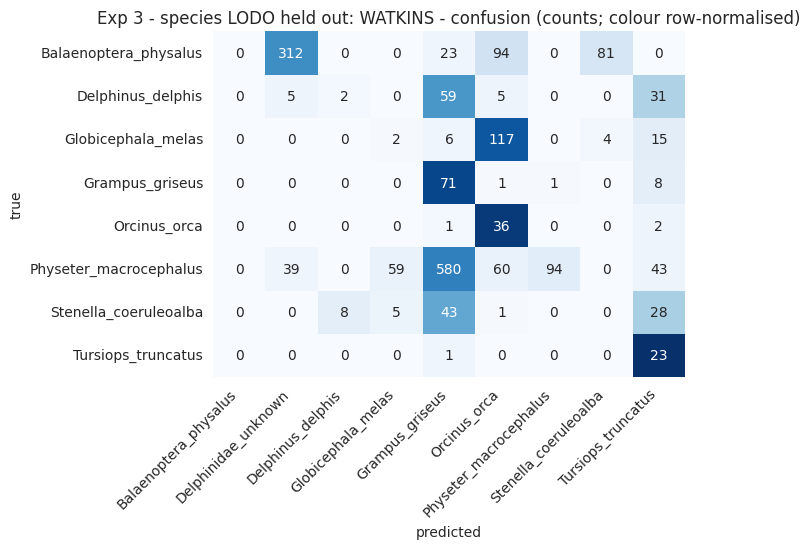


  Exp 3 - species LODO held out: MONISH
  val_macro_f1               = 0.968
  test_macro_f1 (test-only)  = 0.094
  test_macro_f1 (full vocab) = 0.047
  test_weighted_f1           = 0.081
  test_accuracy              = 0.091
  test_balanced_acc          = 0.187
  trained in 8.4s

  test set contains 5 / 10 classes: ['Balaenoptera_physalus', 'Globicephala_melas', 'Grampus_griseus', 'Orcinus_orca', 'Tursiops_truncatus']

                       precision    recall  f1-score   support

Balaenoptera_physalus      0.000     0.000     0.000        29
   Globicephala_melas      0.096     0.012     0.022       410
      Grampus_griseus      0.610     0.221     0.325       113
         Orcinus_orca      0.068     0.703     0.123        37
   Tursiops_truncatus      0.000     0.000     0.000        28

            micro avg      0.117     0.091     0.102       617
            macro avg      0.155     0.187     0.094       617
         weighted avg      0.180     0.091     0.081       617



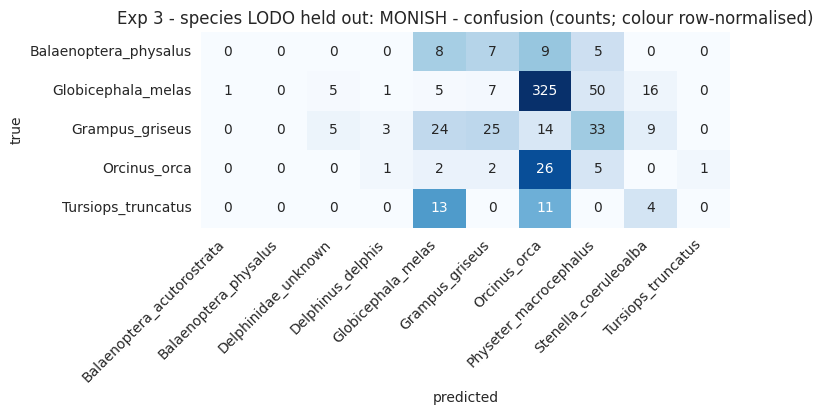


  Exp 3 - species LODO held out: ECOSS_testtrain
  val_macro_f1               = 0.964
  test_macro_f1 (test-only)  = 0.542
  test_macro_f1 (full vocab) = 0.271
  test_weighted_f1           = 0.450
  test_accuracy              = 0.472
  test_balanced_acc          = 0.577
  trained in 4.9s

  test set contains 5 / 10 classes: ['Delphinus_delphis', 'Globicephala_melas', 'Orcinus_orca', 'Physeter_macrocephalus', 'Tursiops_truncatus']

                        precision    recall  f1-score   support

     Delphinus_delphis      0.000     0.000     0.000        40
    Globicephala_melas      1.000     0.231     0.375        26
          Orcinus_orca      0.600     0.955     0.737        22
Physeter_macrocephalus      1.000     0.700     0.824        20
    Tursiops_truncatus      0.633     1.000     0.776        19

             micro avg      0.706     0.472     0.566       127
             macro avg      0.647     0.577     0.542       127
          weighted avg      0.561     0.472     0.

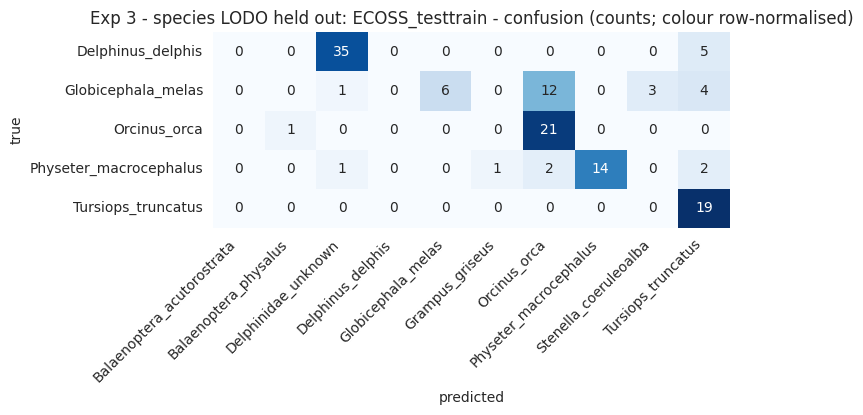


  Exp 3 - species LODO held out: ALNITAK_CAVANILLES
  val_macro_f1               = 0.919
  test_macro_f1 (test-only)  = 0.090
  test_macro_f1 (full vocab) = 0.045
  test_weighted_f1           = 0.152
  test_accuracy              = 0.087
  test_balanced_acc          = 0.051
  trained in 5.1s

  test set contains 5 / 10 classes: ['Globicephala_melas', 'Grampus_griseus', 'Physeter_macrocephalus', 'Stenella_coeruleoalba', 'Tursiops_truncatus']

                        precision    recall  f1-score   support

    Globicephala_melas      1.000     0.078     0.145       141
       Grampus_griseus      0.125     0.022     0.038        45
Physeter_macrocephalus      0.862     0.140     0.240       179
 Stenella_coeruleoalba      0.000     0.000     0.000        15
    Tursiops_truncatus      0.045     0.017     0.025        58

             micro avg      0.514     0.087     0.148       438
             macro avg      0.407     0.051     0.090       438
          weighted avg      0.693     0.

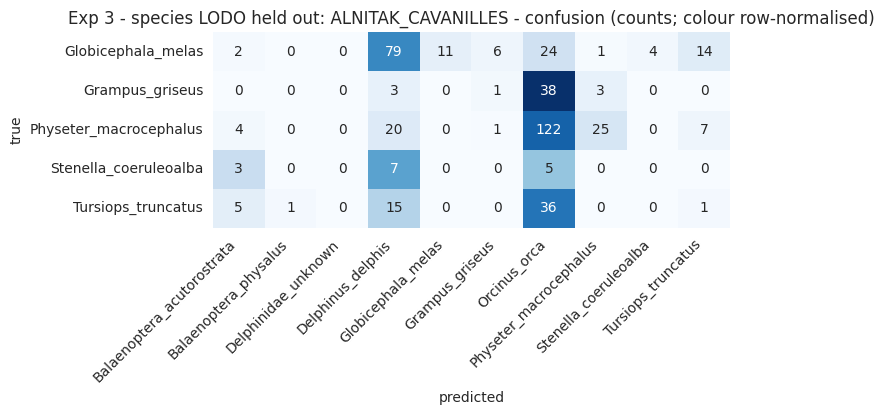

In [37]:
for ds, r in results_species_lodo.items():
    report_run(f"Exp 3 - species LODO held out: {ds}", r, max_classes_cm=20)

## 6. Cross-comparison

Where the same dataset appears as a held-out fold in both joint LODO (Exp 2) and
pure species LODO (Exp 3), we can compare directly. The species-restricted metric
of Exp 2 should be in the same ballpark as Exp 3's macro-F1.

A large gap signals that adding background to the training (Exp 2) hurts or helps
species transfer - depending on direction - relative to a species-only head (Exp 3).


In [38]:
shared = set(JOINT_LODO_HOLDOUTS) & set(SPECIES_LODO_HOLDOUTS)
rows = []
for ds in sorted(shared):
    j = results_joint_lodo.get(ds)
    s = results_species_lodo.get(ds)
    if j is None or s is None: continue
    rows.append({
        'held_out': ds,
        'exp2_joint_species_only_macro_f1':   j['sp_macro_f1'],
        'exp3_pure_species_macro_f1':         s['test_macro_f1'],
        'delta (exp2 - exp3)':                (j['sp_macro_f1'] - s['test_macro_f1'])
                                              if j['sp_macro_f1'] is not None else None,
        'exp2_n_species_test_rows':           j['sp_n_test_rows'],
        'exp3_n_test_rows':                   s['n_test'],
        'exp2_frac_species_routed_to_bg':     j['sp_frac_routed_to_bg'],
    })
compare = pd.DataFrame(rows)
print(compare.to_string(index=False))
compare.to_csv(OUT_DIR / 'exp2_vs_exp3_comparison.csv', index=False)


          held_out  exp2_joint_species_only_macro_f1  exp3_pure_species_macro_f1  delta (exp2 - exp3)  exp2_n_species_test_rows  exp3_n_test_rows  exp2_frac_species_routed_to_bg
ALNITAK_CAVANILLES                          0.017871                    0.089571            -0.071701                       438               438                        0.885845
   ECOSS_testtrain                          0.488671                    0.542176            -0.053505                       127               127                        0.047244
            MONISH                          0.075210                    0.093909            -0.018699                       617               617                        0.278768


In [39]:
summary_all = []
summary_all.append({
    'experiment': 'Exp 1a - flat joint (within-corpus)',
    'macro_f1':         exp1a['test_macro_f1'],
    'macro_f1_full':    exp1a['test_macro_f1_full_vocab'],
    'accuracy':         exp1a['test_accuracy'],
    'balanced_acc':     exp1a['test_balanced_acc'],
    'note':             'one head over {bg, all species}',
})
summary_all.append({
    'experiment': 'Exp 1b - hierarchical cascade (within-corpus)',
    'macro_f1':         cascade_res['test_macro_f1'],
    'macro_f1_full':    cascade_res['test_macro_f1_full_vocab'],
    'accuracy':         cascade_res['test_accuracy'],
    'balanced_acc':     cascade_res['test_balanced_acc'],
    'note':             'binary detector -> species head',
})
summary_all.append({
    'experiment': 'Exp 2 - joint LODO (mean across folds)',
    'macro_f1':         float(np.mean([r['test_macro_f1']            for r in results_joint_lodo.values()])),
    'macro_f1_full':    float(np.mean([r['test_macro_f1_full_vocab'] for r in results_joint_lodo.values()])),
    'accuracy':         float(np.mean([r['test_accuracy']            for r in results_joint_lodo.values()])),
    'balanced_acc':     float(np.mean([r['test_balanced_acc']        for r in results_joint_lodo.values()])),
    'note':             'mean per-fold; see exp2_joint_lodo_summary.csv',
})
sp_macros_exp2 = [r['sp_macro_f1'] for r in results_joint_lodo.values()
                  if r['sp_macro_f1'] is not None]
if sp_macros_exp2:
    summary_all.append({
        'experiment': 'Exp 2 - joint LODO species-restricted (mean)',
        'macro_f1':         float(np.mean(sp_macros_exp2)),
        'macro_f1_full':    float('nan'),
        'accuracy':         float('nan'),
        'balanced_acc':     float(np.mean([r['sp_balanced_acc'] for r in results_joint_lodo.values()
                                           if r['sp_balanced_acc'] is not None])),
        'note':             'mammal-test-rows only - apples-to-apples vs Exp 3',
    })
summary_all.append({
    'experiment': 'Exp 3 - species LODO (mean across folds)',
    'macro_f1':         float(np.mean([r['test_macro_f1']            for r in results_species_lodo.values()])),
    'macro_f1_full':    float(np.mean([r['test_macro_f1_full_vocab'] for r in results_species_lodo.values()])),
    'accuracy':         float(np.mean([r['test_accuracy']            for r in results_species_lodo.values()])),
    'balanced_acc':     float(np.mean([r['test_balanced_acc']        for r in results_species_lodo.values()])),
    'note':             'mean per-fold; see exp3_species_lodo_summary.csv',
})
df_all = pd.DataFrame(summary_all)
print(df_all.to_string(index=False))
df_all.to_csv(OUT_DIR / 'summary_all_experiments.csv', index=False)


                                   experiment  macro_f1  macro_f1_full  accuracy  balanced_acc                                              note
          Exp 1a - flat joint (within-corpus)  0.731316       0.731316  0.857687      0.892509                   one head over {bg, all species}
Exp 1b - hierarchical cascade (within-corpus)  0.735837       0.735837  0.910773      0.811568                   binary detector -> species head
       Exp 2 - joint LODO (mean across folds)  0.441675       0.107379  0.534192      0.450158    mean per-fold; see exp2_joint_lodo_summary.csv
 Exp 2 - joint LODO species-restricted (mean)  0.401438            NaN       NaN      0.338642 mammal-test-rows only - apples-to-apples vs Exp 3
     Exp 3 - species LODO (mean across folds)  0.208948       0.115181  0.193135      0.294520  mean per-fold; see exp3_species_lodo_summary.csv


## 7. Persist artefacts

In [40]:
def save_preds(name, r):
    rows_te = r.get('rows_te')
    classes = r.get('classes', r.get('class_names'))
    if rows_te is None or classes is None:
        print(f"  skip {name}: no rows_te / classes")
        return
    df = meta_all.iloc[rows_te][['dataset','region','environment','group_key',
                                 'label_t1','label_t2','label_t3','label_t4','label_t5']].copy()
    df['y_true_idx'] = r['yte']
    df['y_pred_idx'] = r['ypr']
    df['y_true']     = [classes[i] for i in r['yte']]
    df['y_pred']     = [classes[i] for i in r['ypr']]
    fp = OUT_DIR / f'preds_{name}.parquet'
    df.to_parquet(fp, index=False)

# Exp 1
save_preds('exp1a_flat_joint', exp1a)
save_preds('exp1b_detector',   det)
save_preds('exp1b_species_head_oracle', sp_head)
cascade_for_save = dict(cascade_res)
cascade_for_save['rows_te'] = exp1_meta_te['row'].values
save_preds('exp1b_cascade', cascade_for_save)

# Exp 2
for ds, r in results_joint_lodo.items():
    save_preds(f'exp2_joint_lodo_{ds}', r)

# Exp 3
for ds, r in results_species_lodo.items():
    save_preds(f'exp3_species_lodo_{ds}', r)

print(f"\nall artefacts in {OUT_DIR.resolve()}")
for fp in sorted(OUT_DIR.iterdir()):
    print(f"  {fp.name}")



all artefacts in /data2/mromaniuc/cet-det/alltogether/full_exploration/classifiers/mlp_runs
  exp1_joint_vs_hierarchical.csv
  exp2_joint_lodo_summary.csv
  exp2_vs_exp3_comparison.csv
  exp3_species_lodo_summary.csv
  preds_exp1a_flat_joint.parquet
  preds_exp1b_cascade.parquet
  preds_exp1b_detector.parquet
  preds_exp1b_species_head_oracle.parquet
  preds_exp2_joint_lodo_ALNITAK_CAVANILLES.parquet
  preds_exp2_joint_lodo_Adriatic_Sea.parquet
  preds_exp2_joint_lodo_DCLDE_2026.parquet
  preds_exp2_joint_lodo_DOLPHINFREE.parquet
  preds_exp2_joint_lodo_DRYAD.parquet
  preds_exp2_joint_lodo_ECOSS_annot.parquet
  preds_exp2_joint_lodo_ECOSS_enhanced.parquet
  preds_exp2_joint_lodo_ECOSS_testtrain.parquet
  preds_exp2_joint_lodo_FREMANTLE.parquet
  preds_exp2_joint_lodo_MONISH.parquet
  preds_exp2_joint_lodo_OLTREMARE.parquet
  preds_exp3_species_lodo_ALNITAK_CAVANILLES.parquet
  preds_exp3_species_lodo_ECOSS_testtrain.parquet
  preds_exp3_species_lodo_MONISH.parquet
  preds_exp3_specie

## 8. Few-shot seeded LODO

Pure LODO is intentionally harsh: the model never sees the acoustic domain
of the held-out dataset.

This experiment tests how performance changes if we provide a tiny labelled
"seed set" from the held-out dataset itself.

Protocol:
- keep the original LODO split,
- randomly sample `k` examples per class from the held-out dataset,
- move those rows into training,
- evaluate on the remaining held-out rows.

This simulates realistic deployment where a small amount of local annotation
is available.

In [8]:
def make_seeded_split(
    meta_df,
    held_out,
    label_col,
    k_per_class=5,
    random_state=42,
):
    """
    Build train/test for seeded LODO.

    For each class in the held-out dataset:
        - sample k rows
        - move them into training
        - keep the rest for testing
    """

    rng = np.random.RandomState(random_state)

    train_meta = meta_df[meta_df['dataset'] != held_out].copy()

    held_meta = meta_df[meta_df['dataset'] == held_out].copy()

    seed_parts = []
    test_parts = []

    for cls, grp in held_meta.groupby(label_col):

        grp = grp.sample(frac=1.0, random_state=random_state)

        n_seed = min(k_per_class, len(grp) - 1)

        if n_seed <= 0:
            continue

        seed_parts.append(grp.iloc[:n_seed])
        test_parts.append(grp.iloc[n_seed:])

    if len(seed_parts) == 0 or len(test_parts) == 0:
        return None

    seed_meta = pd.concat(seed_parts).copy()
    test_meta = pd.concat(test_parts).copy()

    train_meta = pd.concat([train_meta, seed_meta], ignore_index=True)

    return train_meta, test_meta, seed_meta

In [11]:
SEEDED_K = [4, 16, 32]

seeded_joint_results = []   # one row per (k, held_out) fold — now keeps yte/ypr
seeded_seed_counts   = []   # one row per (k, held_out, class) — actual seeds used

for k in SEEDED_K:

    print(f"\n{'='*80}")
    print(f"SEEDED JOINT LODO  |  k={k}")
    print(f"{'='*80}")

    for held_out in JOINT_LODO_HOLDOUTS:

        print(f"\n--- {held_out} ---")

        out = make_seeded_split(
            meta_joint,
            held_out=held_out,
            label_col='label_joint',
            k_per_class=k,
            random_state=42,
        )

        if out is None:
            print("skip")
            continue

        train_meta, test_meta, seed_meta = out

        # record actual seeds taken per class for this fold (before class filtering)
        for cls, n_taken in seed_meta['label_joint'].value_counts().items():
            seeded_seed_counts.append({
                'k': k, 'held_out': held_out,
                'class': cls, 'n_seed_used': int(n_taken),
            })

        # keep only trainable classes
        counts = train_meta['label_joint'].value_counts()
        keep = set(counts[counts >= 20].index)

        train_meta = train_meta[train_meta['label_joint'].isin(keep)].copy()
        test_meta  = test_meta[test_meta['label_joint'].isin(keep)].copy()

        if len(test_meta) == 0:
            print("no valid test rows")
            continue

        le = LabelEncoder().fit(sorted(keep))
        train_meta['y'] = le.transform(train_meta['label_joint'].astype(str))
        test_meta['y']  = le.transform(test_meta['label_joint'].astype(str))

        tr_pos, va_pos = split_train_val(train_meta, val_size=0.1, random_state=42)

        Xtr = np.asarray(X_all[train_meta.iloc[tr_pos]['row'].values], dtype=np.float32)
        Xva = np.asarray(X_all[train_meta.iloc[va_pos]['row'].values], dtype=np.float32)
        Xte = np.asarray(X_all[test_meta['row'].values],                dtype=np.float32)

        ytr = train_meta.iloc[tr_pos]['y'].values
        yva = train_meta.iloc[va_pos]['y'].values
        yte = test_meta['y'].values

        r = train_eval_mlp(
            Xtr, ytr, Xva, yva, Xte, yte,
            n_classes=len(le.classes_),
            class_names=list(le.classes_),
            verbose=False,
        )

        seeded_joint_results.append({
            'k': k,
            'held_out': held_out,
            'macro_f1':     r['test_macro_f1'],
            'weighted_f1':  r['test_weighted_f1'],
            'accuracy':     r['test_accuracy'],
            'balanced_acc': r['test_balanced_acc'],
            'n_seed_rows':  len(seed_meta),
            'n_test_rows':  len(test_meta),
            # keep per-fold predictions for per-class analysis
            'yte':                 r['yte'],
            'ypr':                 r['ypr'],
            'class_names':         r['class_names'],
            'test_classes_present': r['test_classes_present'],
        })

        print(
            f"macro_f1={r['test_macro_f1']:.3f}  "
            f"acc={r['test_accuracy']:.3f}"
        )

seeded_seed_counts_df = pd.DataFrame(seeded_seed_counts)


SEEDED JOINT LODO  |  k=4

--- OLTREMARE ---
macro_f1=0.771  acc=0.839

--- MONISH ---
macro_f1=0.607  acc=0.702

--- FREMANTLE ---
macro_f1=0.785  acc=0.646

--- ECOSS_testtrain ---
macro_f1=0.223  acc=0.943

--- ECOSS_enhanced ---
macro_f1=0.681  acc=0.576

--- ECOSS_annot ---
macro_f1=0.699  acc=0.653

--- DRYAD ---
macro_f1=0.703  acc=0.629

--- DOLPHINFREE ---
macro_f1=0.749  acc=0.657

--- DCLDE_2026 ---
macro_f1=0.631  acc=0.673

--- Adriatic_Sea ---
macro_f1=0.684  acc=0.813

--- ALNITAK_CAVANILLES ---
macro_f1=0.197  acc=0.530

SEEDED JOINT LODO  |  k=16

--- OLTREMARE ---
macro_f1=0.756  acc=0.824

--- MONISH ---
macro_f1=0.812  acc=0.879

--- FREMANTLE ---
macro_f1=0.875  acc=0.778

--- ECOSS_testtrain ---
macro_f1=0.184  acc=0.871

--- ECOSS_enhanced ---
macro_f1=0.758  acc=0.671

--- ECOSS_annot ---
macro_f1=0.698  acc=0.654

--- DRYAD ---
macro_f1=0.673  acc=0.619

--- DOLPHINFREE ---
macro_f1=0.714  acc=0.644

--- DCLDE_2026 ---
macro_f1=0.504  acc=0.487

--- Adriatic_S

In [12]:
from pathlib import Path
import pandas as pd
import pickle
import json
import numpy as np

OUT_DIR = Path("seeded_joint_lodo_results")
OUT_DIR.mkdir(exist_ok=True, parents=True)

# ------------------------------------------------------------
# Save compact metrics CSV
# ------------------------------------------------------------

compact_rows = []

for row in seeded_joint_results:

    compact_rows.append({
        k: v
        for k, v in row.items()
        if k not in ['yte', 'ypr']
    })

compact_df = pd.DataFrame(compact_rows)

compact_df.to_csv(
    OUT_DIR / "seeded_joint_results_metrics.csv",
    index=False
)

# ------------------------------------------------------------
# Save seed count info
# ------------------------------------------------------------

seeded_seed_counts_df.to_csv(
    OUT_DIR / "seeded_seed_counts.csv",
    index=False
)

# ------------------------------------------------------------
# Save FULL python object (recommended)
# preserves predictions exactly
# ------------------------------------------------------------

with open(OUT_DIR / "seeded_joint_results_full.pkl", "wb") as f:
    pickle.dump(seeded_joint_results, f)

# ------------------------------------------------------------
# Optional JSON export
# easier to inspect manually
# ------------------------------------------------------------

json_ready = []

for row in seeded_joint_results:

    clean_row = {}

    for k, v in row.items():

        if isinstance(v, np.ndarray):
            clean_row[k] = v.tolist()
        else:
            clean_row[k] = v

    json_ready.append(clean_row)

with open(OUT_DIR / "seeded_joint_results_full.json", "w") as f:
    json.dump(json_ready, f, indent=2)

print(f"\nSaved all results to: {OUT_DIR.resolve()}")


Saved all results to: /data2/mromaniuc/cet-det/alltogether/full_exploration/classifiers/seeded_joint_lodo_results


In [13]:
# Per-fold per-class reports for every (k, held_out)
for fold in seeded_joint_results:
    classes = fold['class_names']
    present = fold['test_classes_present']
    if classes is None or present is None:
        continue

    present_names = [classes[i] for i in present]
    name = f"Seeded LODO  |  k={fold['k']}  held_out={fold['held_out']}"
    print(f"\n{'='*72}\n  {name}\n{'='*72}")
    print(f"  macro_f1={fold['macro_f1']:.3f}  "
          f"weighted_f1={fold['weighted_f1']:.3f}  "
          f"acc={fold['accuracy']:.3f}  "
          f"bal_acc={fold['balanced_acc']:.3f}")
    print(f"  test contains {len(present)} / {len(classes)} classes\n")
    print(classification_report(
        fold['yte'], fold['ypr'],
        labels=present, target_names=present_names,
        digits=3, zero_division=0,
    ))


  Seeded LODO  |  k=4  held_out=OLTREMARE
  macro_f1=0.771  weighted_f1=0.855  acc=0.839  bal_acc=0.817
  test contains 2 / 10 classes

                    precision    recall  f1-score   support

Tursiops_truncatus      0.544     0.785     0.643      2900
        background      0.953     0.850     0.899     13952

         micro avg      0.850     0.839     0.845     16852
         macro avg      0.749     0.817     0.771     16852
      weighted avg      0.883     0.839     0.855     16852


  Seeded LODO  |  k=4  held_out=MONISH
  macro_f1=0.607  weighted_f1=0.757  acc=0.702  bal_acc=0.564
  test contains 5 / 10 classes

                       precision    recall  f1-score   support

Balaenoptera_physalus      1.000     0.800     0.889        25
   Globicephala_melas      0.898     0.761     0.824       406
      Grampus_griseus      0.763     0.651     0.703       109
         Orcinus_orca      0.356     0.485     0.410        33
   Tursiops_truncatus      0.600     0.125     0.2

In [14]:
# Build per-(k, held_out, class) recall rows from stored predictions
recall_rows = []
for fold in seeded_joint_results:
    classes = fold['class_names']
    if classes is None:
        continue
    rep = classification_report(
        fold['yte'], fold['ypr'],
        labels=fold['test_classes_present'],
        target_names=[classes[i] for i in fold['test_classes_present']],
        output_dict=True, zero_division=0,
    )
    for cls_name in [classes[i] for i in fold['test_classes_present']]:
        d = rep.get(cls_name, {})
        recall_rows.append({
            'k': fold['k'],
            'held_out': fold['held_out'],
            'class': cls_name,
            'recall': d.get('recall', np.nan),
            'precision': d.get('precision', np.nan),
            'f1': d.get('f1-score', np.nan),
            'support': int(d.get('support', 0)),
        })

recall_df = pd.DataFrame(recall_rows)

# Per-class recall averaged across the holdouts where the class appears
per_class_recall = (
    recall_df
    .groupby(['class', 'k'])['recall']
    .mean()
    .unstack('k')
    .sort_index()
)
print("\nPer-class recall  (mean over holdouts where class present):\n")
print(per_class_recall.round(3).to_string())

# How many holdouts each class shows up in (sanity check on the means above)
n_folds = (
    recall_df
    .groupby(['class', 'k'])['held_out']
    .nunique()
    .unstack('k')
    .sort_index()
)
print("\nNumber of holdout folds contributing to each cell:\n")
print(n_folds.to_string())

# Cross-reference with actual seeds available (some classes can't reach k=32)
mean_seeds = (
    seeded_seed_counts_df
    .groupby(['class', 'k'])['n_seed_used']
    .mean()
    .unstack('k')
    .sort_index()
)
print("\nMean seeds actually available per class (cap is k):\n")
print(mean_seeds.round(1).to_string())

per_class_recall.to_csv(OUT_DIR / 'seeded_per_class_recall.csv')


Per-class recall  (mean over holdouts where class present):

k                          4      16     32
class                                      
Balaenoptera_physalus   0.800  1.000  1.000
Delphinidae_unknown     0.277  0.554  0.752
Delphinus_delphis       0.419  0.624  0.658
Globicephala_melas      0.658  0.896  0.922
Grampus_griseus         0.338  0.845  0.861
Orcinus_orca            0.637  0.767  0.848
Physeter_macrocephalus  0.715  0.922  0.980
Stenella_coeruleoalba   0.818  1.000  1.000
Tursiops_truncatus      0.620  0.796  0.841
background              0.622  0.488  0.454

Number of holdout folds contributing to each cell:

k                       4   16  32
class                             
Balaenoptera_physalus    1   1   1
Delphinidae_unknown      2   2   2
Delphinus_delphis        2   2   2
Globicephala_melas       3   3   3
Grampus_griseus          2   2   2
Orcinus_orca             4   4   4
Physeter_macrocephalus   3   3   3
Stenella_coeruleoalba    2   2   2
Tursiop

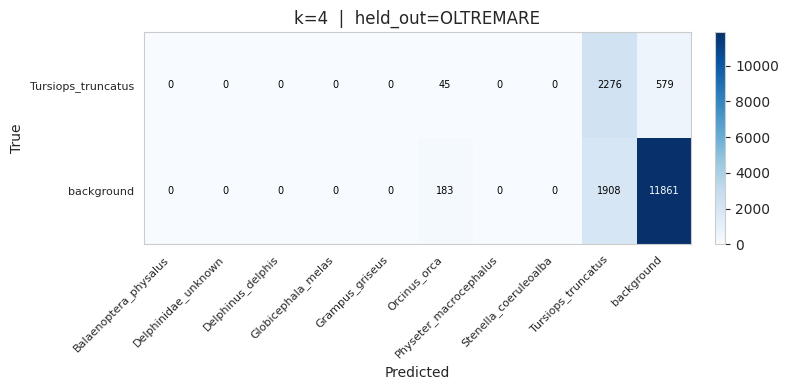

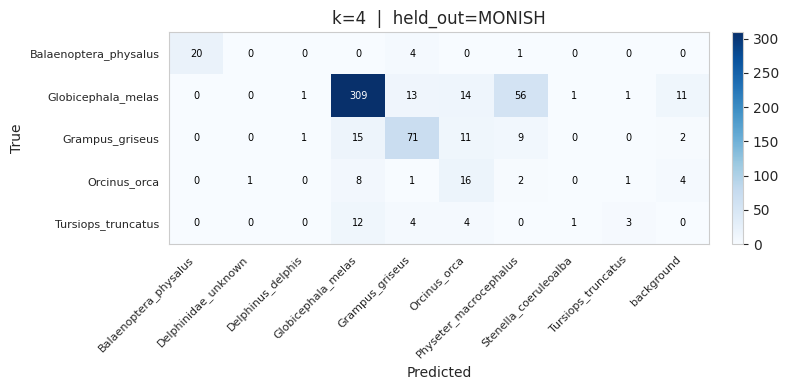

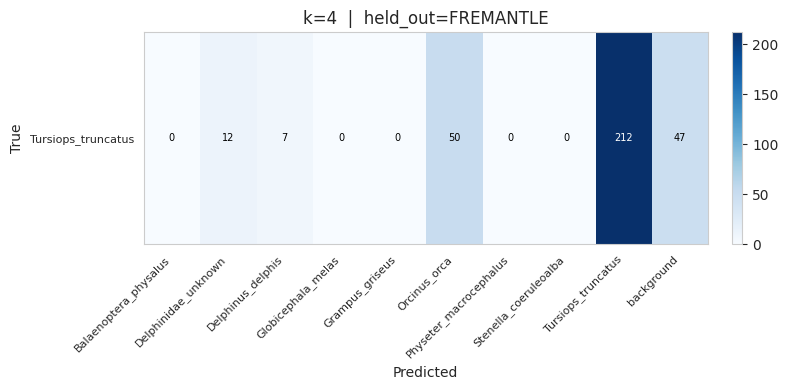

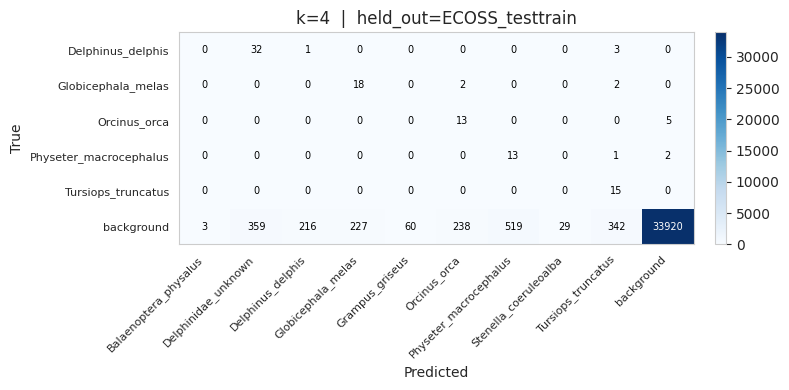

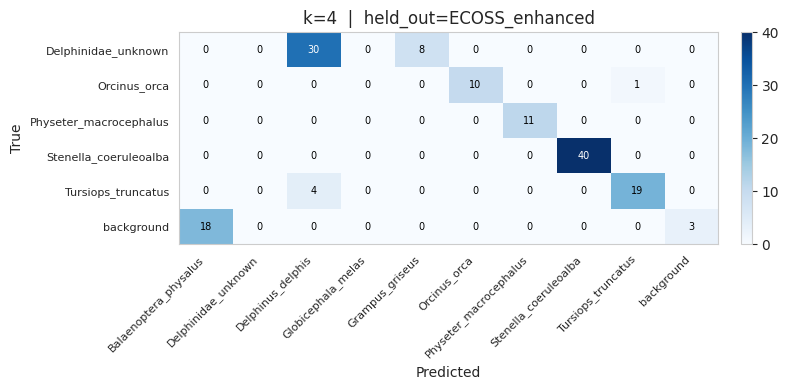

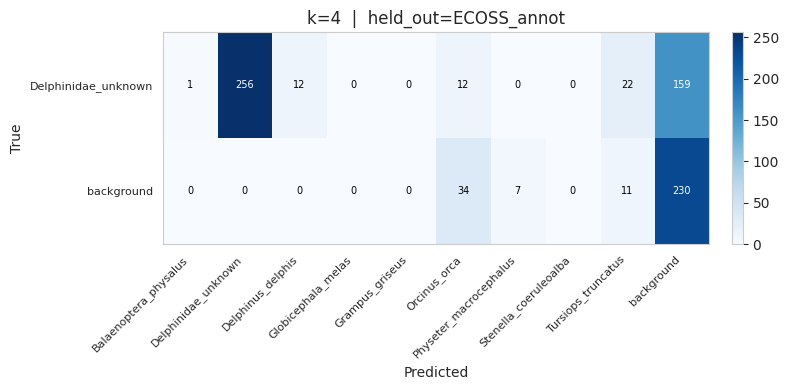

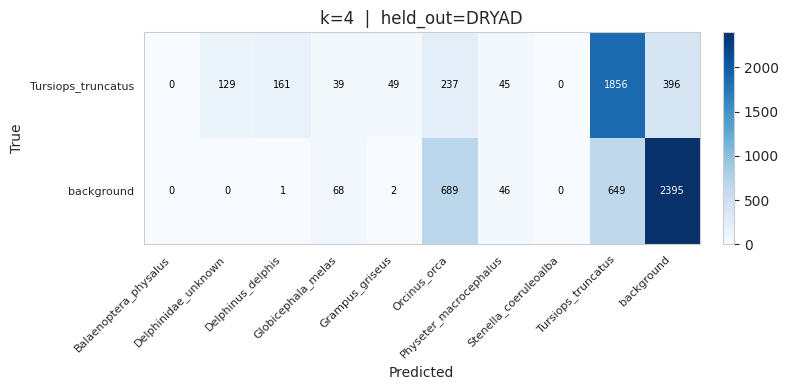

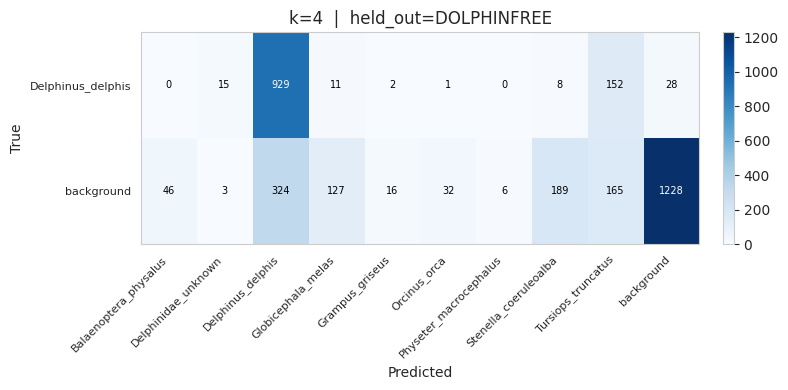

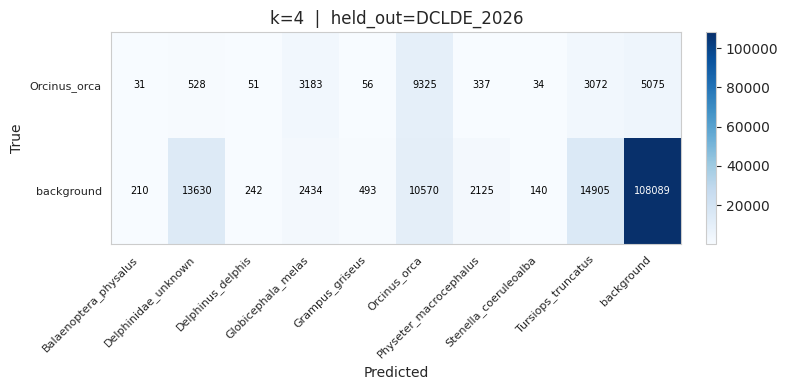

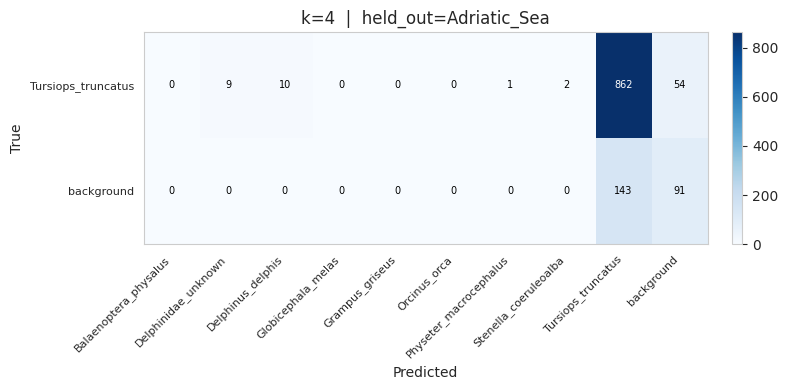

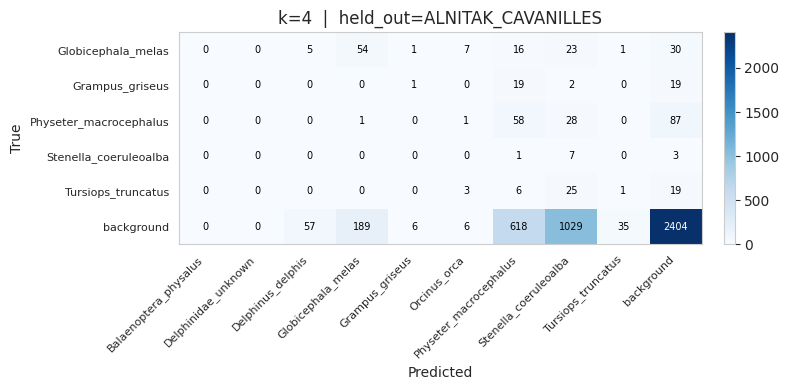

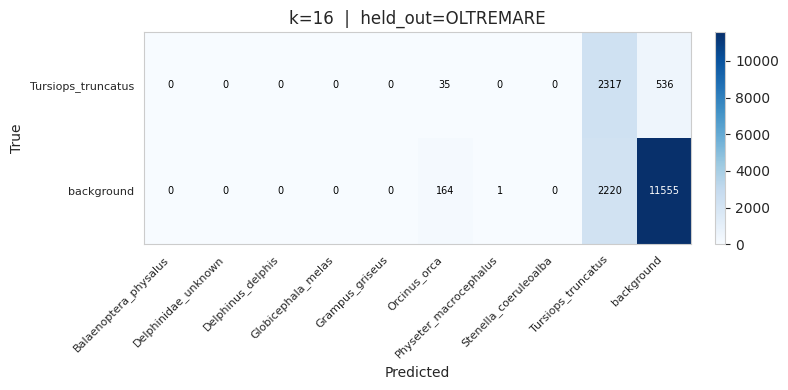

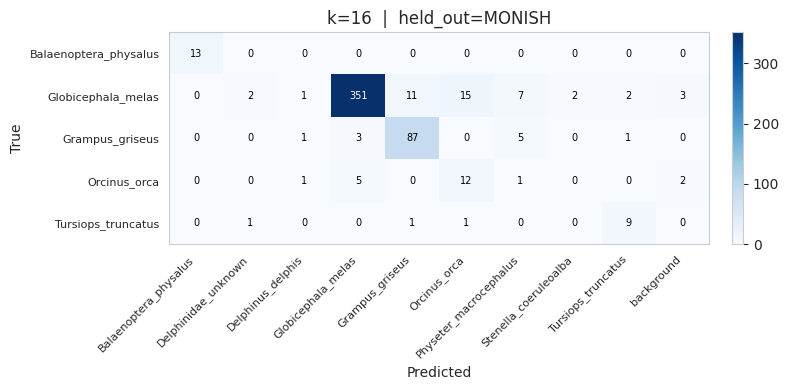

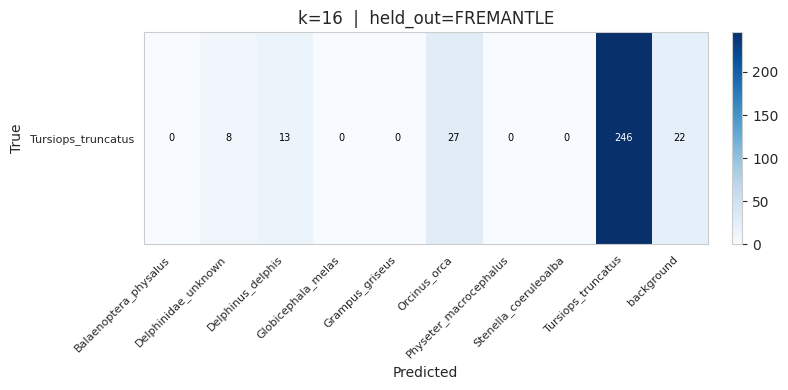

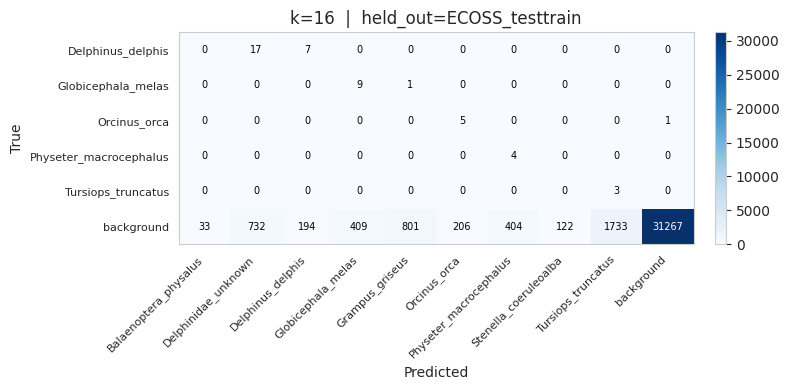

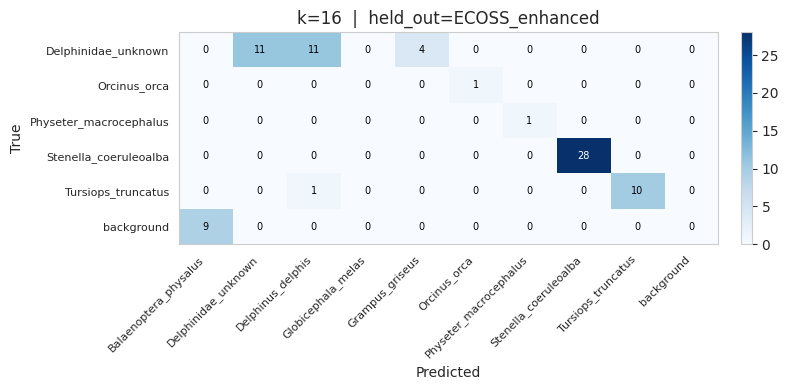

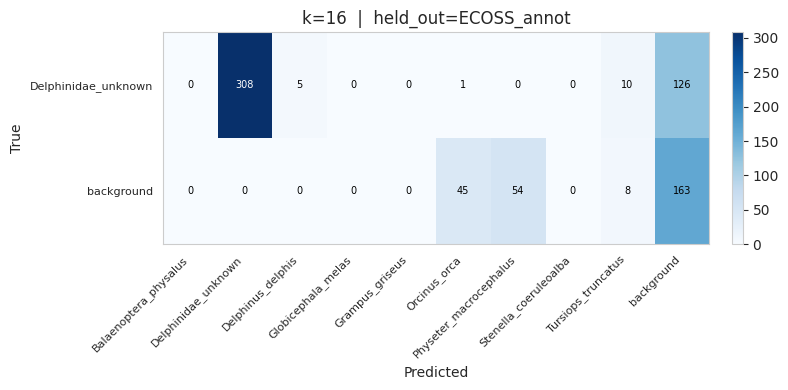

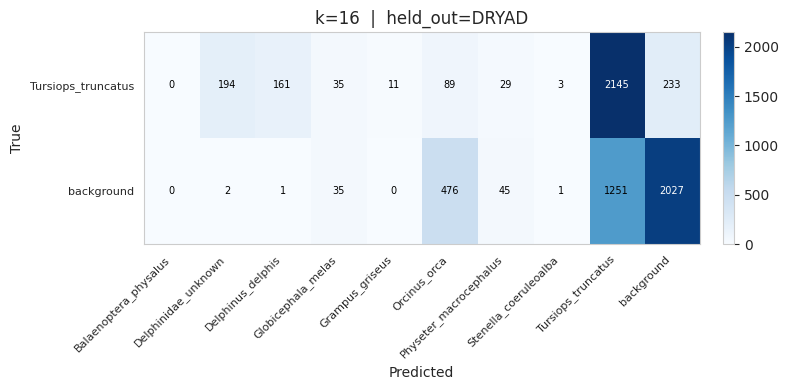

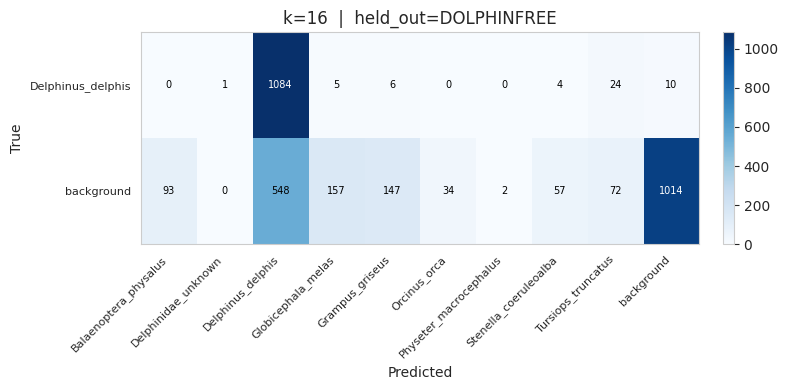

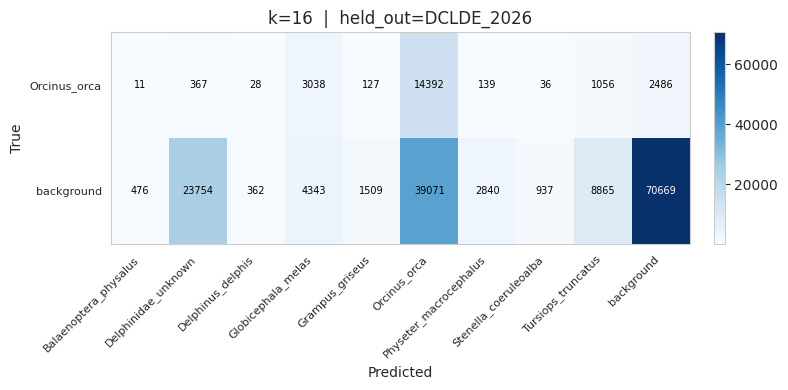

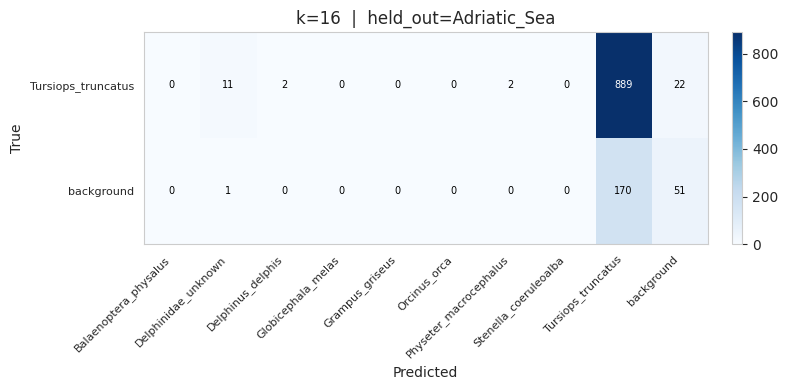

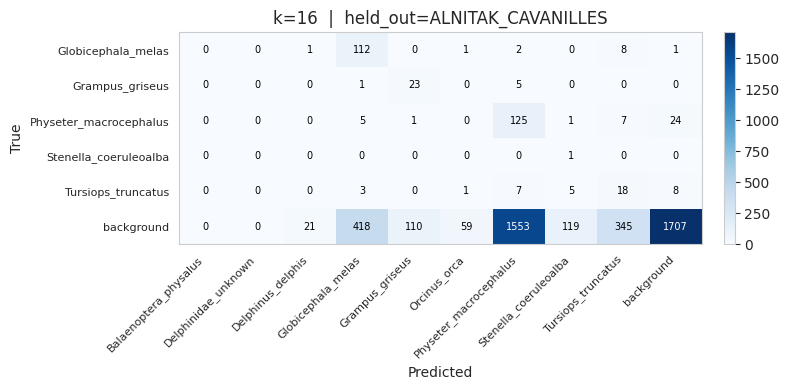

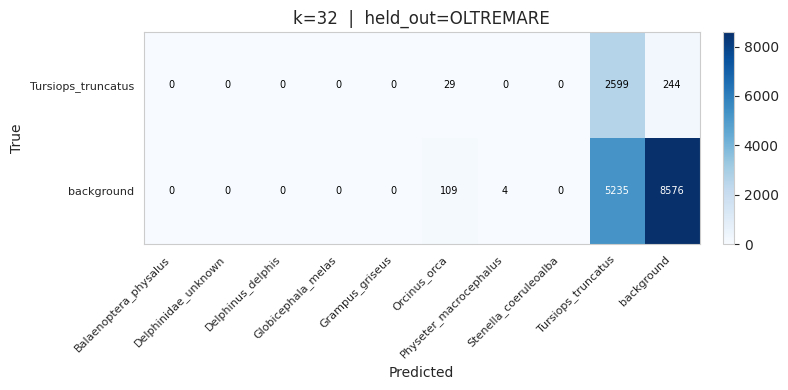

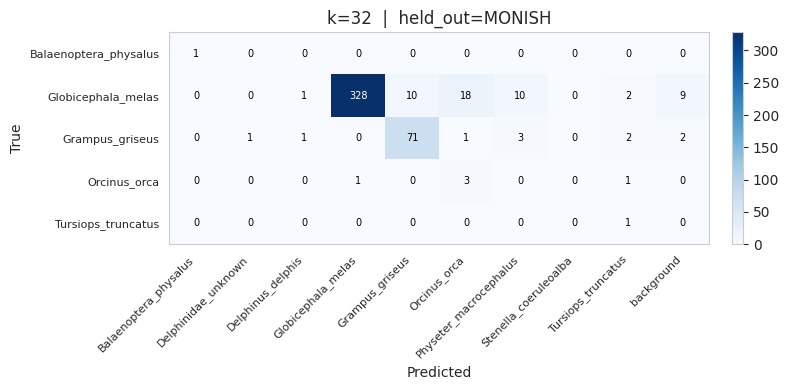

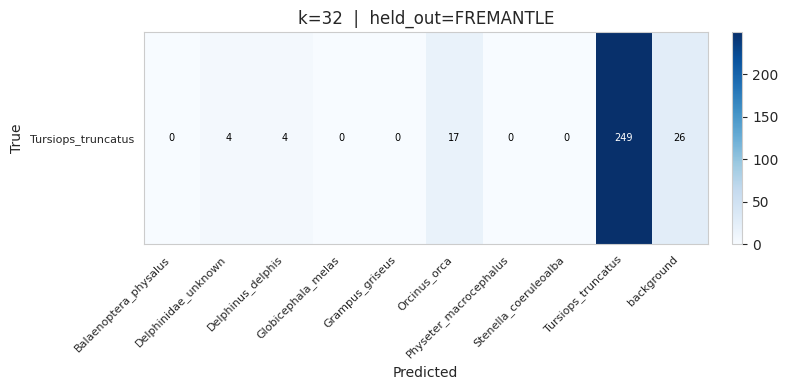

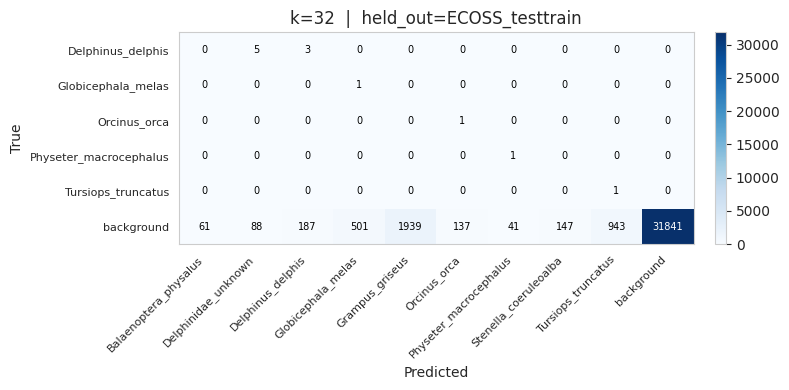

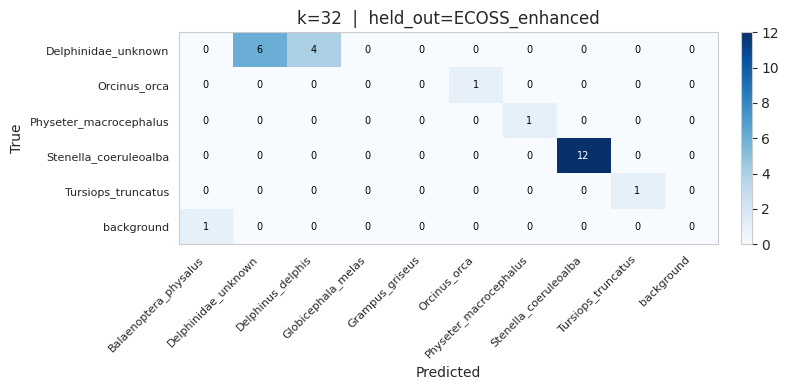

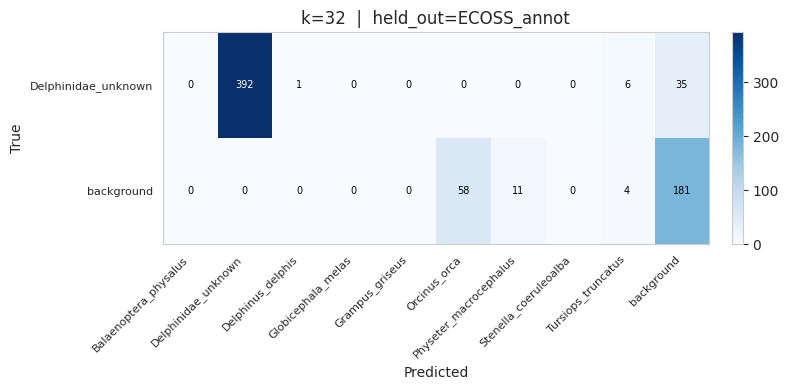

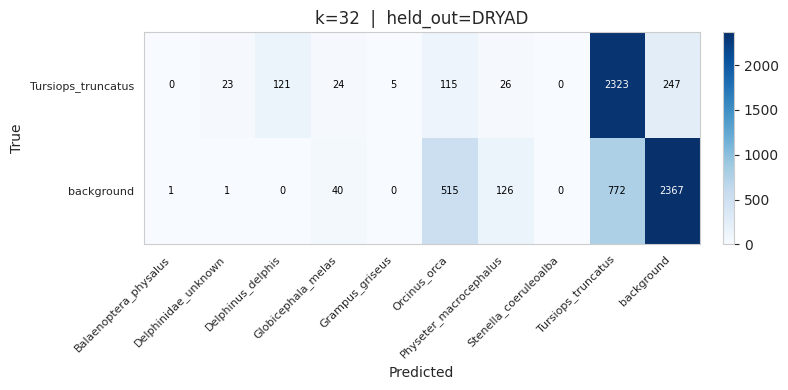

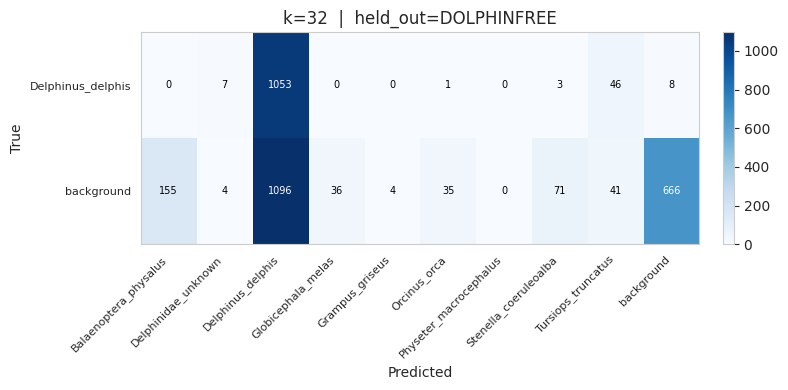

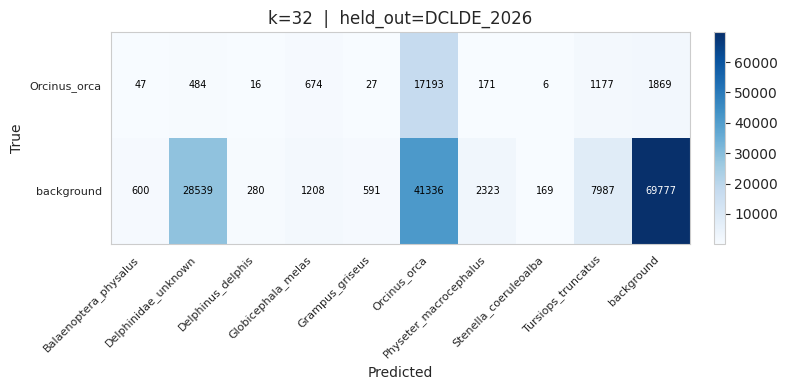

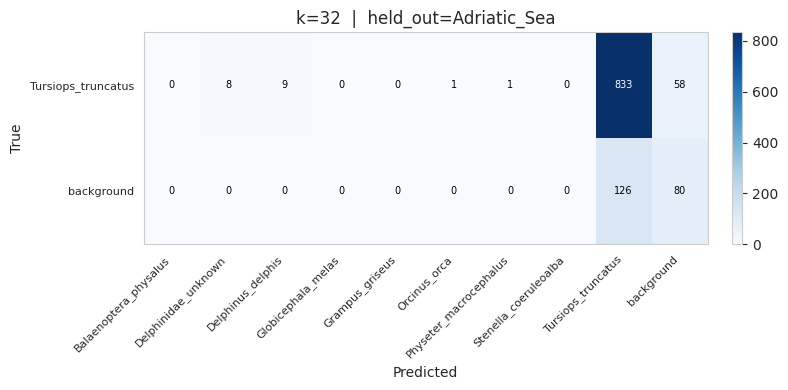

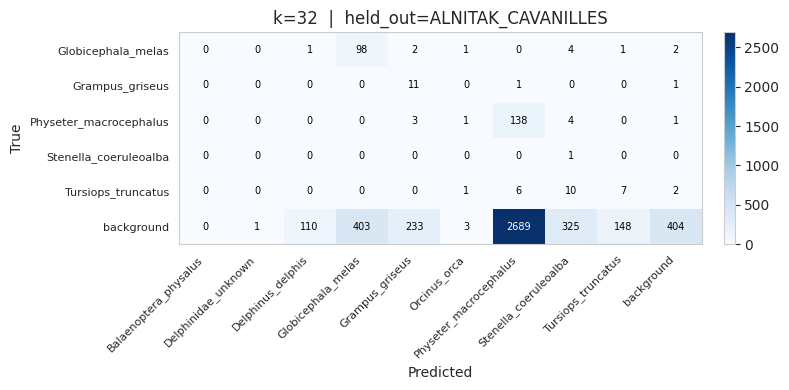

saved 33 confusion matrices to ./seeded_joint_confusion_matrices/


In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CM_DIR = "seeded_joint_confusion_matrices"
os.makedirs(CM_DIR, exist_ok=True)

cm_records = []

for row in seeded_joint_results:
    k                    = row['k']
    held_out             = row['held_out']
    yte                  = np.asarray(row['yte'])
    ypr                  = np.asarray(row['ypr'])
    class_names          = list(row['class_names'])
    test_classes_present = list(row['test_classes_present'])

    n_all  = len(class_names)
    n_true = len(test_classes_present)

    # build cm manually: rows = true classes present, cols = all predicted classes
    cm = np.zeros((n_true, n_all), dtype=int)
    for i, true_cls in enumerate(test_classes_present):
        mask = yte == true_cls
        for j in range(n_all):
            cm[i, j] = np.sum(ypr[mask] == j)

    y_labels = [class_names[i] for i in test_classes_present]
    x_labels = class_names

    safe_held = str(held_out).replace('/', '_').replace(' ', '_')
    csv_path  = os.path.join(CM_DIR, f"cm_k{k}_{safe_held}.csv")
    pd.DataFrame(cm, index=y_labels, columns=x_labels).to_csv(csv_path)

    n_rows, n_cols = len(y_labels), len(x_labels)
    fig, ax = plt.subplots(figsize=(max(8, n_cols * 0.5), max(4, n_rows * 0.5)))

    im = ax.imshow(cm, aspect='auto', cmap='Blues')
    plt.colorbar(im, ax=ax, fraction=0.02, pad=0.04)

    ax.set_xticks(range(n_cols))
    ax.set_yticks(range(n_rows))
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(y_labels, fontsize=8)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(f"k={k}  |  held_out={held_out}")
    ax.grid(False)

    for i in range(n_rows):
        for j in range(n_cols):
            ax.text(j, i, str(cm[i, j]), ha='center', va='center',
                    fontsize=7, color='white' if cm[i, j] > cm.max() * 0.6 else 'black')

    fig.tight_layout()
    png_path = os.path.join(CM_DIR, f"cm_k{k}_{safe_held}.png")
    fig.savefig(png_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close(fig)

    cm_records.append({
        'k': k, 'held_out': held_out,
        'cm': cm, 'y_labels': y_labels, 'x_labels': x_labels,
        'csv_path': csv_path, 'png_path': png_path,
    })

seeded_joint_cms = pd.DataFrame(cm_records)
print(f"saved {len(cm_records)} confusion matrices to ./{CM_DIR}/")

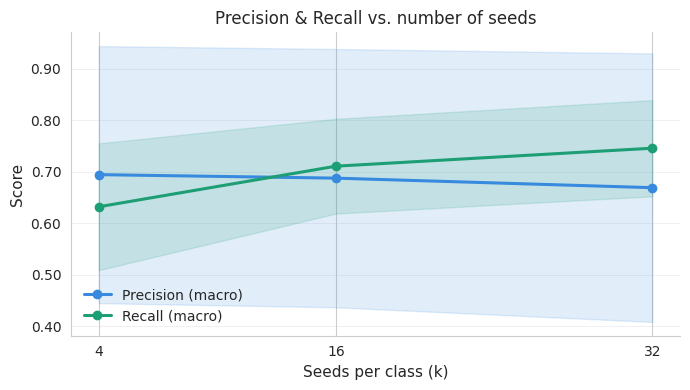

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import precision_score, recall_score

records = []

for row in seeded_joint_results:
    yte = np.asarray(row['yte'])
    ypr = np.asarray(row['ypr'])
    present = list(row['test_classes_present'])

    records.append({
        'k':        row['k'],
        'held_out': row['held_out'],
        'precision': precision_score(yte, ypr, labels=present, average='macro', zero_division=0),
        'recall':    recall_score(   yte, ypr, labels=present, average='macro', zero_division=0),
    })

df = pd.DataFrame(records)
summary = df.groupby('k').agg(
    prec_mean=('precision','mean'), prec_std=('precision','std'),
    rec_mean=('recall',   'mean'), rec_std=('recall',   'std'),
).reset_index()

fig, ax = plt.subplots(figsize=(7, 4))

BLUE   = '#378ADD'
TEAL   = '#1D9E75'
ALPHA  = 0.15

for col_mean, col_std, color, label in [
    ('prec_mean', 'prec_std', BLUE,  'Precision (macro)'),
    ('rec_mean',  'rec_std',  TEAL,  'Recall (macro)'),
]:
    ax.plot(summary['k'], summary[col_mean], color=color, linewidth=2.2,
            marker='o', markersize=6, label=label, zorder=3)
    ax.fill_between(
        summary['k'],
        summary[col_mean] - summary[col_std],
        summary[col_mean] + summary[col_std],
        color=color, alpha=ALPHA,
    )

ax.set_xlabel('Seeds per class (k)', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Precision & Recall vs. number of seeds', fontsize=12, fontweight='normal')
ax.set_xticks(summary['k'])
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
ax.spines[['top','right']].set_visible(False)
ax.grid(axis='y', linewidth=0.5, alpha=0.4)
ax.legend(frameon=False, fontsize=10)

fig.tight_layout()
fig.savefig('precision_recall_vs_seeds.png', dpi=150, bbox_inches='tight')
plt.show()